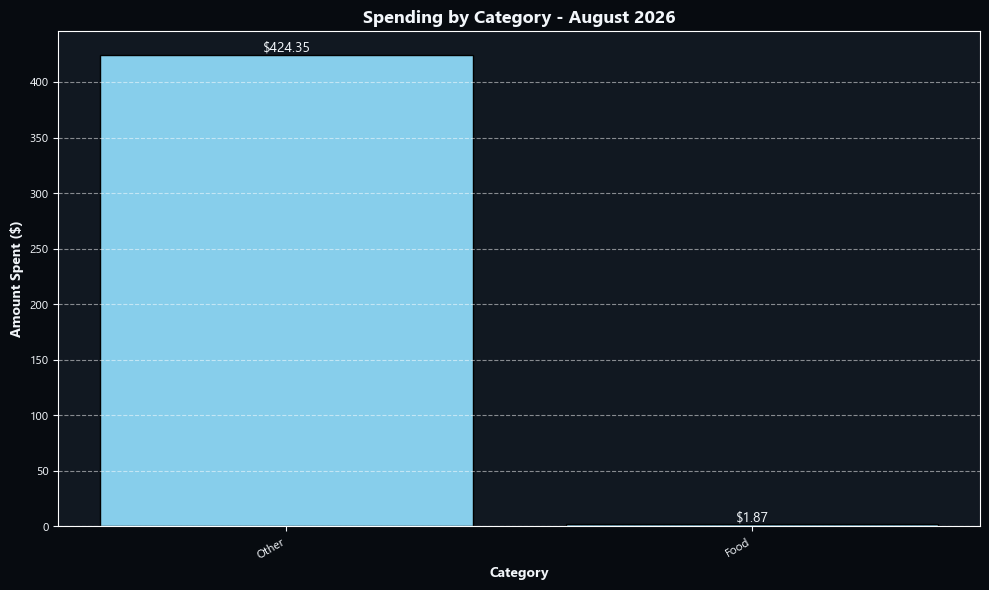

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your Excel file
file_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\ExpenseTracker.xlsx"

# Read Excel file
df = pd.read_excel(file_path)

# Convert Date and Amount columns
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Remove rows with missing Date, Category, or Amount
df = df.dropna(subset=["Date", "Category", "Amount"])

# Use the latest month found in your spreadsheet
latest_date = df["Date"].max()

df_month = df[
    (df["Date"].dt.year == latest_date.year) &
    (df["Date"].dt.month == latest_date.month)
]

# Group by Category and total the Amount
category_totals = (
    df_month
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Create vertical bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_totals.index,
    category_totals.values,
    color="skyblue",
    edgecolor="black"
)

# Chart labels
plt.title(f"Spending by Category - {latest_date.strftime('%B %Y')}")
plt.xlabel("Category")
plt.ylabel("Amount Spent ($)")

# Add dollar amounts above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.2f}",
        ha="center",
        va="bottom"
    )

# Improve readability
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# Show chart
plt.show()

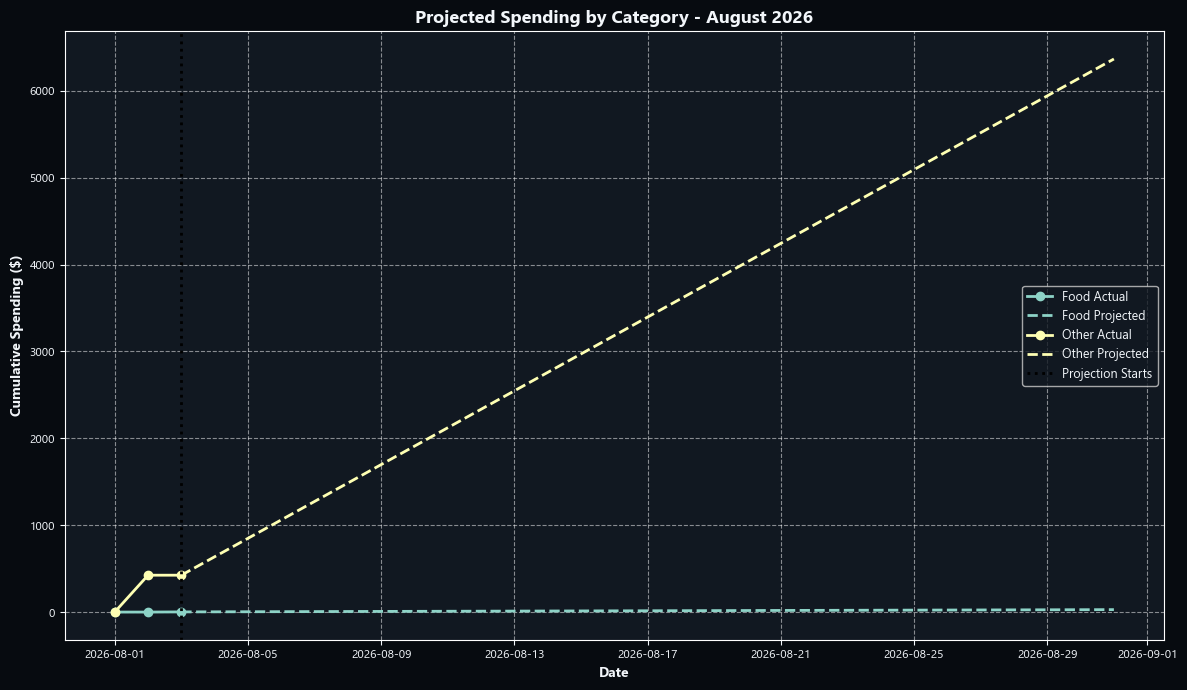

Projected spending through August 31, 2026:
--------------------------------------------------
Food: $28.05
Other: $6,365.25
--------------------------------------------------
Projected Total Spending: $6,393.30


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import calendar

# Path to your Excel file
file_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\ExpenseTracker.xlsx"

# Read Excel file
df = pd.read_excel(file_path)

# Clean columns
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Remove incomplete rows
df = df.dropna(subset=["Date", "Category", "Amount"])

# Use latest month in the spreadsheet
latest_date = df["Date"].max()
year = latest_date.year
month = latest_date.month

# Get number of days in that month
days_in_month = calendar.monthrange(year, month)[1]

# Filter to latest month
df_month = df[
    (df["Date"].dt.year == year) &
    (df["Date"].dt.month == month)
].copy()

# Normalize dates to remove time portion
df_month["Date"] = df_month["Date"].dt.normalize()

# Create full date range for the month
month_start = pd.Timestamp(year=year, month=month, day=1)
month_end = pd.Timestamp(year=year, month=month, day=days_in_month)

actual_dates = pd.date_range(month_start, latest_date.normalize(), freq="D")
full_month_dates = pd.date_range(month_start, month_end, freq="D")

plt.figure(figsize=(12, 7))

projection_summary = {}

# Loop through each spending category
for category in sorted(df_month["Category"].unique()):
    category_df = df_month[df_month["Category"] == category]

    # Daily spending for this category
    daily_spending = (
        category_df
        .groupby("Date")["Amount"]
        .sum()
        .reindex(actual_dates, fill_value=0)
    )

    # Cumulative spending so far
    cumulative_actual = daily_spending.cumsum()

    # X values are day numbers: 1, 2, 3, etc.
    x_actual = np.array([date.day for date in actual_dates])
    y_actual = cumulative_actual.values

    # Linear regression using numpy
    slope, intercept = np.polyfit(x_actual, y_actual, 1)

    # Future dates including latest actual date through end of month
    projection_dates = pd.date_range(latest_date.normalize(), month_end, freq="D")
    x_projection = np.array([date.day for date in projection_dates])

    # Anchor projection at actual current spending to avoid graph jump
    current_total = y_actual[-1]
    latest_day = latest_date.day

    y_projection = current_total + slope * (x_projection - latest_day)

    # Prevent projection from going below current total
    y_projection = np.maximum(y_projection, current_total)

    # Store projected final amount
    projection_summary[category] = y_projection[-1]

    # Plot actual cumulative spending
    actual_line, = plt.plot(
        actual_dates,
        y_actual,
        marker="o",
        linewidth=2,
        label=f"{category} Actual"
    )

    # Use same color for projection
    color = actual_line.get_color()

    # Plot projected cumulative spending
    plt.plot(
        projection_dates,
        y_projection,
        linestyle="--",
        linewidth=2,
        color=color,
        label=f"{category} Projected"
    )

# Add vertical line for today's/latest data date
plt.axvline(
    latest_date.normalize(),
    color="black",
    linestyle=":",
    linewidth=2,
    label="Projection Starts"
)

plt.title(f"Projected Spending by Category - {latest_date.strftime('%B %Y')}")
plt.xlabel("Date")
plt.ylabel("Cumulative Spending ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Print projected totals
print(f"Projected spending through {month_end.strftime('%B %d, %Y')}:")
print("-" * 50)

grand_total = 0

for category, projected_total in projection_summary.items():
    print(f"{category}: ${projected_total:,.2f}")
    grand_total += projected_total

print("-" * 50)
print(f"Projected Total Spending: ${grand_total:,.2f}")

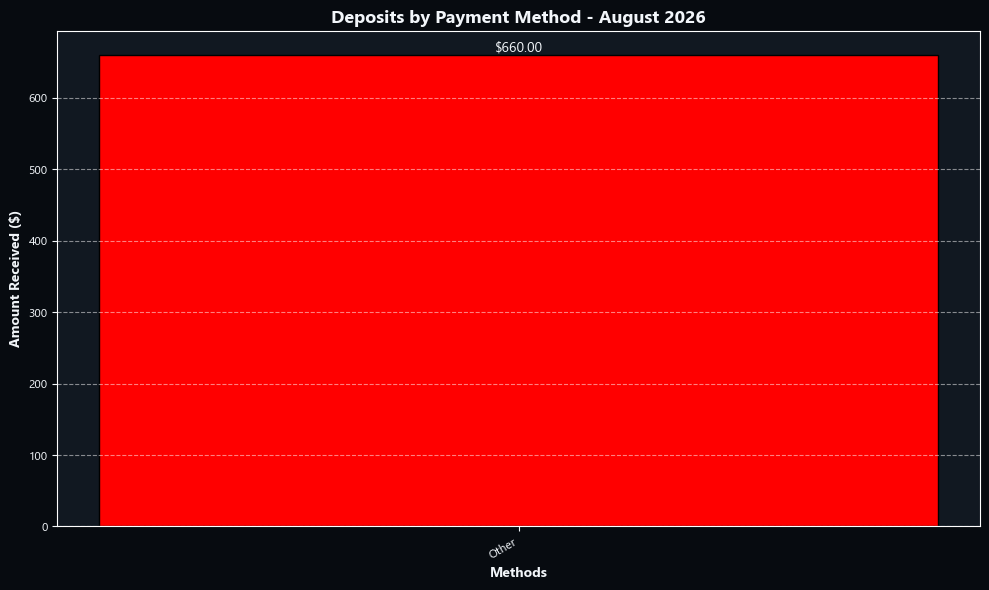

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Change this to whichever file you are charting
file_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\Cashflow.xlsx"

# Read Excel file
df = pd.read_excel(file_path)

# Convert Date and Amount columns
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Remove rows with missing values
df = df.dropna(subset=["Date", "PaymentMethod", "Amount"])

# Use latest month in the spreadsheet
latest_date = df["Date"].max()

df_month = df[
    (df["Date"].dt.year == latest_date.year) &
    (df["Date"].dt.month == latest_date.month)
]

# Group by PaymentMethod
totals = (
    df_month
    .groupby("PaymentMethod")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Custom colors
color_map = {
    "Transfer": "orange",
    "Other": "red",
    "Direct Deposit": "lightgreen",
    "Rewards": "blue",
    "Cash Deposit": "skyblue"
}

# Assign colors to each bar
bar_colors = [
    color_map.get(label, "gray")
    for label in totals.index
]

# Create vertical bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    totals.index,
    totals.values,
    color=bar_colors,
    edgecolor="black"
)

plt.title(f"Deposits by Payment Method - {latest_date.strftime('%B %Y')}")
plt.xlabel("Methods")
plt.ylabel("Amount Received ($)")

# Add dollar labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\207133\AppData\Local\Temp\ipykernel_34800\3614809306.py:45: RankWarning:

Polyfit may be poorly conditioned



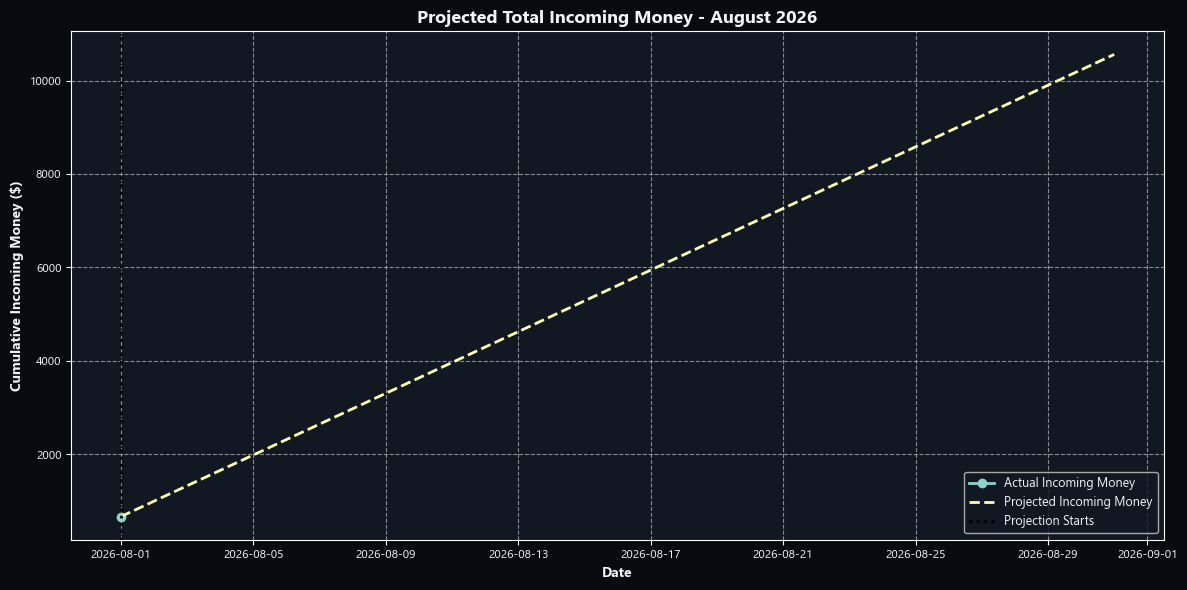

Current incoming money so far: $660.00
Projected incoming money by August 31, 2026: $10,560.00


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import calendar

file_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\Cashflow.xlsx"

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

df = df.dropna(subset=["Date", "Amount"])

latest_date = df["Date"].max()
year = latest_date.year
month = latest_date.month
days_in_month = calendar.monthrange(year, month)[1]

df_month = df[
    (df["Date"].dt.year == year) &
    (df["Date"].dt.month == month)
].copy()

df_month["Date"] = df_month["Date"].dt.normalize()

month_start = pd.Timestamp(year=year, month=month, day=1)
month_end = pd.Timestamp(year=year, month=month, day=days_in_month)

actual_dates = pd.date_range(month_start, latest_date.normalize(), freq="D")
projection_dates = pd.date_range(latest_date.normalize(), month_end, freq="D")

daily_income = (
    df_month
    .groupby("Date")["Amount"]
    .sum()
    .reindex(actual_dates, fill_value=0)
)

cumulative_actual = daily_income.cumsum()

x_actual = np.array([date.day for date in actual_dates])
y_actual = cumulative_actual.values

slope, intercept = np.polyfit(x_actual, y_actual, 1)

x_projection = np.array([date.day for date in projection_dates])

current_total = y_actual[-1]
latest_day = latest_date.day

y_projection = current_total + slope * (x_projection - latest_day)
y_projection = np.maximum(y_projection, current_total)

projected_final_total = y_projection[-1]

plt.figure(figsize=(12, 6))

plt.plot(
    actual_dates,
    y_actual,
    marker="o",
    linewidth=2,
    label="Actual Incoming Money"
)

plt.plot(
    projection_dates,
    y_projection,
    linestyle="--",
    linewidth=2,
    label="Projected Incoming Money"
)

plt.axvline(
    latest_date.normalize(),
    color="black",
    linestyle=":",
    linewidth=2,
    label="Projection Starts"
)

plt.title(f"Projected Total Incoming Money - {latest_date.strftime('%B %Y')}")
plt.xlabel("Date")
plt.ylabel("Cumulative Incoming Money ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

print(f"Current incoming money so far: ${current_total:,.2f}")
print(f"Projected incoming money by {month_end.strftime('%B %d, %Y')}: ${projected_final_total:,.2f}")

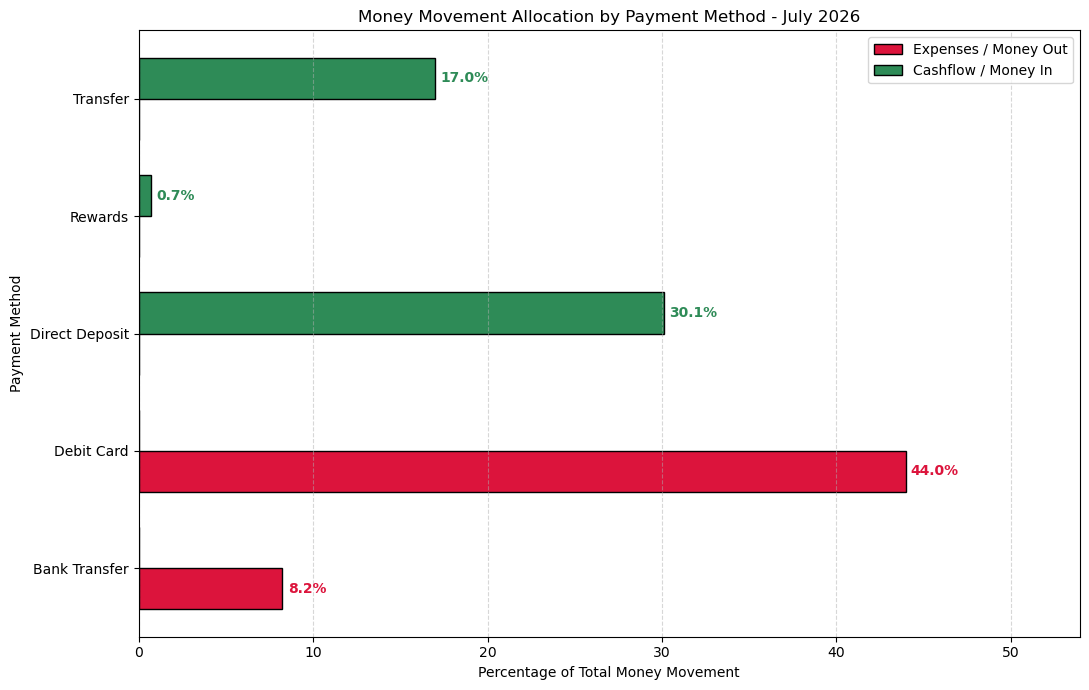

Expense percentages:
PaymentMethod
Debit Card        43.96%
Bank Transfer      8.25%
Direct Deposit      0.0%
Rewards             0.0%
Transfer            0.0%
Name: Amount, dtype: object

Cashflow percentages:
PaymentMethod
Direct Deposit    30.1%
Transfer          17.0%
Rewards           0.69%
Bank Transfer      0.0%
Debit Card         0.0%
Name: Amount, dtype: object

Combined total percentage:
100.00%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
expense_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\ExpenseTracker.xlsx"
cashflow_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\Cashflow.xlsx"

# Read Excel files
expenses = pd.read_excel(expense_path)
cashflow = pd.read_excel(cashflow_path)

# Clean columns
expenses["Date"] = pd.to_datetime(expenses["Date"], errors="coerce")
expenses["Amount"] = pd.to_numeric(expenses["Amount"], errors="coerce")

cashflow["Date"] = pd.to_datetime(cashflow["Date"], errors="coerce")
cashflow["Amount"] = pd.to_numeric(cashflow["Amount"], errors="coerce")

# Drop incomplete rows
expenses = expenses.dropna(subset=["Date", "PaymentMethod", "Amount"])
cashflow = cashflow.dropna(subset=["Date", "PaymentMethod", "Amount"])

# Use the latest month found across both files
latest_date = max(expenses["Date"].max(), cashflow["Date"].max())

year = latest_date.year
month = latest_date.month

# Filter both files to the same month
expenses_month = expenses[
    (expenses["Date"].dt.year == year) &
    (expenses["Date"].dt.month == month)
]

cashflow_month = cashflow[
    (cashflow["Date"].dt.year == year) &
    (cashflow["Date"].dt.month == month)
]

# Group totals by payment method
expense_totals = expenses_month.groupby("PaymentMethod")["Amount"].sum()
cashflow_totals = cashflow_month.groupby("PaymentMethod")["Amount"].sum()

# Combined grand total: expenses + cashflow
grand_total = expense_totals.sum() + cashflow_totals.sum()

# Convert to percentage of combined total
expense_percentages = (expense_totals / grand_total) * 100
cashflow_percentages = (cashflow_totals / grand_total) * 100

# Combine all payment methods from both files
all_payment_methods = sorted(
    set(expense_percentages.index).union(set(cashflow_percentages.index))
)

# Reindex so both series use the same payment method list
expense_percentages = expense_percentages.reindex(all_payment_methods, fill_value=0)
cashflow_percentages = cashflow_percentages.reindex(all_payment_methods, fill_value=0)

# Chart positions
y = np.arange(len(all_payment_methods))
bar_height = 0.35

plt.figure(figsize=(11, 7))

# Expense bars
expense_bars = plt.barh(
    y - bar_height / 2,
    expense_percentages.values,
    height=bar_height,
    color="crimson",
    edgecolor="black",
    label="Expenses / Money Out"
)

# Cashflow bars
cashflow_bars = plt.barh(
    y + bar_height / 2,
    cashflow_percentages.values,
    height=bar_height,
    color="seagreen",
    edgecolor="black",
    label="Cashflow / Money In"
)

# Add labels to expense bars
for bar in expense_bars:
    width = bar.get_width()
    if width > 0:
        plt.text(
            width + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            color="crimson",
            fontweight="bold"
        )

# Add labels to cashflow bars
for bar in cashflow_bars:
    width = bar.get_width()
    if width > 0:
        plt.text(
            width + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            color="seagreen",
            fontweight="bold"
        )

plt.yticks(y, all_payment_methods)
plt.xlabel("Percentage of Total Money Movement")
plt.ylabel("Payment Method")
plt.title(f"Money Movement Allocation by Payment Method - {latest_date.strftime('%B %Y')}")
plt.xlim(0, max(expense_percentages.max(), cashflow_percentages.max()) + 10)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

# Print verification
total_percentage = expense_percentages.sum() + cashflow_percentages.sum()

print("Expense percentages:")
print(expense_percentages.sort_values(ascending=False).round(2).astype(str) + "%")

print("\nCashflow percentages:")
print(cashflow_percentages.sort_values(ascending=False).round(2).astype(str) + "%")

print("\nCombined total percentage:")
print(f"{total_percentage:.2f}%")

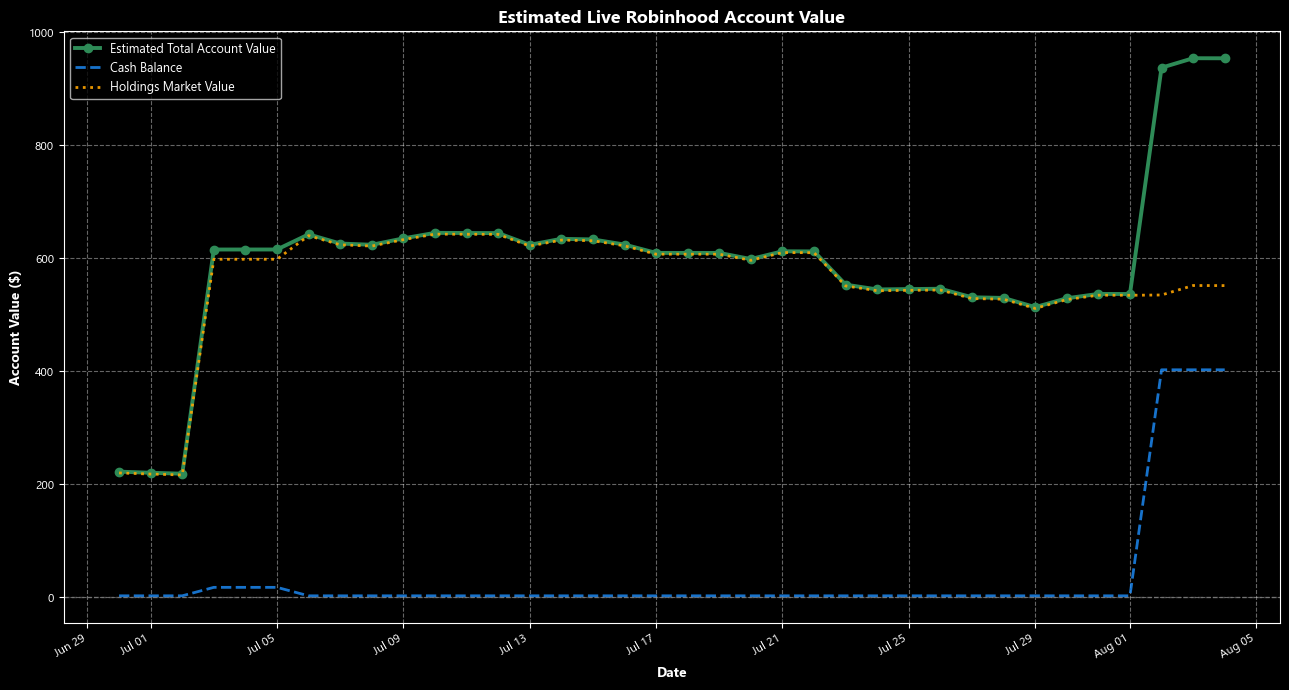

Estimated Live Robinhood Account Value
------------------------------------------------------------
Date: 2026-08-04
Cash Balance: $402.27
Holdings Market Value: $551.28
Estimated Total Account Value: $953.55

Current Holdings:
------------------------------------------------------------
NVDA: 1.000000 units | Price: $206.64 | Market Value: $206.64
ETH-USD: 0.000872 units | Price: $1,870.88 | Market Value: $1.63
TSLA: 1.000000 units | Price: $322.08 | Market Value: $322.08
DOGE-USD: 297.880000 units | Price: $0.07 | Market Value: $20.93


In [4]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["CURL_CA_BUNDLE"] = certifi.where()

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.dates as mdates

from curl_cffi import requests
session = requests.Session(impersonate="chrome")
# =========================
# File path
# =========================
file_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\RobinhoodTracker.xlsx"

# =========================
# Load data
# =========================
df = pd.read_excel(file_path)

# =========================
# Clean data
# =========================
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Transaction"] = df["Transaction"].astype(str).str.strip()
df["AssetType"] = df["AssetType"].astype(str).str.strip()
df["AssetName"] = df["AssetName"].astype(str).str.strip()
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

df = df.dropna(subset=["Date", "Transaction", "Amount"])

# Remove time portion
df["Date"] = df["Date"].dt.normalize()

# =========================
# Map your asset names to market tickers
# Update this as you add more assets
# =========================
ticker_map = {
    "Nvidia": "NVDA",
    "Tesla": "TSLA",
    "Sony": "SONY",
    "Ethereum": "ETH-USD",
    "Doge": "DOGE-USD",
    "Dogecoin": "DOGE-USD"
}

df["Ticker"] = df["AssetName"].map(ticker_map)

# =========================
# Date range
# =========================
start_date = df["Date"].min()
end_date = pd.Timestamp.today().normalize()

# If your file has dates later than today's system date, use latest transaction date
if df["Date"].max() > end_date:
    end_date = df["Date"].max()

date_range = pd.date_range(start_date, end_date, freq="D")

# =========================
# Download market prices
# =========================
tickers = sorted(df["Ticker"].dropna().unique())

if not tickers:
    raise ValueError("No market tickers found. Update ticker_map with your AssetName values.")

price_data = yf.download(
    tickers,
    start=start_date - pd.Timedelta(days=5),
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False
)

# Handle single ticker vs multiple tickers
if len(tickers) == 1:
    close_prices = price_data[["Close"]].copy()
    close_prices.columns = tickers
else:
    close_prices = price_data["Close"].copy()

# Reindex to every calendar day and forward-fill missing prices
close_prices = close_prices.reindex(date_range).ffill()

# =========================
# Account value accounting
# =========================
cash_balance = 0.0
holdings = {}

records = []

df = df.sort_values("Date")

for current_date in date_range:
    todays_transactions = df[df["Date"] == current_date]

    for _, row in todays_transactions.iterrows():
        transaction = row["Transaction"].lower()
        ticker = row["Ticker"]
        quantity = row["Quantity"]
        amount = row["Amount"]

        # -------------------------
        # Cash transactions
        # -------------------------
        if transaction == "deposit":
            cash_balance += abs(amount)

        elif transaction == "withdrawal":
            cash_balance -= abs(amount)

        elif transaction in ["dividend", "interest"]:
            cash_balance += abs(amount)

        elif transaction == "fee":
            cash_balance -= abs(amount)

        # -------------------------
        # Buy transaction
        # -------------------------
        elif transaction == "buy":
            if pd.notna(ticker) and pd.notna(quantity):
                if ticker not in holdings:
                    holdings[ticker] = 0.0

                # Buying does NOT increase account value by itself.
                # It converts cash into holdings.
                cash_balance -= abs(amount)
                holdings[ticker] += quantity

        # -------------------------
        # Sell transaction
        # -------------------------
        elif transaction == "sell":
            if pd.notna(ticker) and pd.notna(quantity):
                if ticker not in holdings:
                    holdings[ticker] = 0.0

                # Selling converts holdings back into cash.
                cash_balance += abs(amount)
                holdings[ticker] -= quantity

                # Prevent tiny negative leftovers
                if abs(holdings[ticker]) < 0.0000001:
                    holdings[ticker] = 0.0

    # Calculate market value of holdings
    holdings_market_value = 0.0

    for ticker, shares in holdings.items():
        if shares > 0:
            try:
                current_price = close_prices.loc[current_date, ticker]

                if pd.notna(current_price):
                    holdings_market_value += shares * current_price
            except Exception:
                pass

    total_account_value = cash_balance + holdings_market_value

    records.append({
        "Date": current_date,
        "CashBalance": cash_balance,
        "HoldingsMarketValue": holdings_market_value,
        "TotalAccountValue": total_account_value
    })

account_value_df = pd.DataFrame(records)

# =========================
# Plot live account value chart
# =========================
plt.figure(figsize=(13, 7))

plt.plot(
    account_value_df["Date"],
    account_value_df["TotalAccountValue"],
    linewidth=2.8,
    marker="o",
    color="seagreen",
    label="Estimated Total Account Value"
)

plt.plot(
    account_value_df["Date"],
    account_value_df["CashBalance"],
    linewidth=2,
    linestyle="--",
    color="dodgerblue",
    alpha=0.8,
    label="Cash Balance"
)

plt.plot(
    account_value_df["Date"],
    account_value_df["HoldingsMarketValue"],
    linewidth=2,
    linestyle=":",
    color="orange",
    alpha=0.9,
    label="Holdings Market Value"
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

plt.title("Estimated Live Robinhood Account Value")
plt.xlabel("Date")
plt.ylabel("Account Value ($)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

# =========================
# Console summary
# =========================
latest = account_value_df.iloc[-1]

print("Estimated Live Robinhood Account Value")
print("-" * 60)
print(f"Date: {latest['Date'].strftime('%Y-%m-%d')}")
print(f"Cash Balance: ${latest['CashBalance']:,.2f}")
print(f"Holdings Market Value: ${latest['HoldingsMarketValue']:,.2f}")
print(f"Estimated Total Account Value: ${latest['TotalAccountValue']:,.2f}")

print("\nCurrent Holdings:")
print("-" * 60)

for ticker, shares in holdings.items():
    if shares > 0:
        try:
            latest_price = close_prices[ticker].dropna().iloc[-1]
            market_value = shares * latest_price

            print(
                f"{ticker}: {shares:,.6f} units "
                f"| Price: ${latest_price:,.2f} "
                f"| Market Value: ${market_value:,.2f}"
            )
        except Exception:
            print(f"{ticker}: {shares:,.6f} units | Price unavailable")

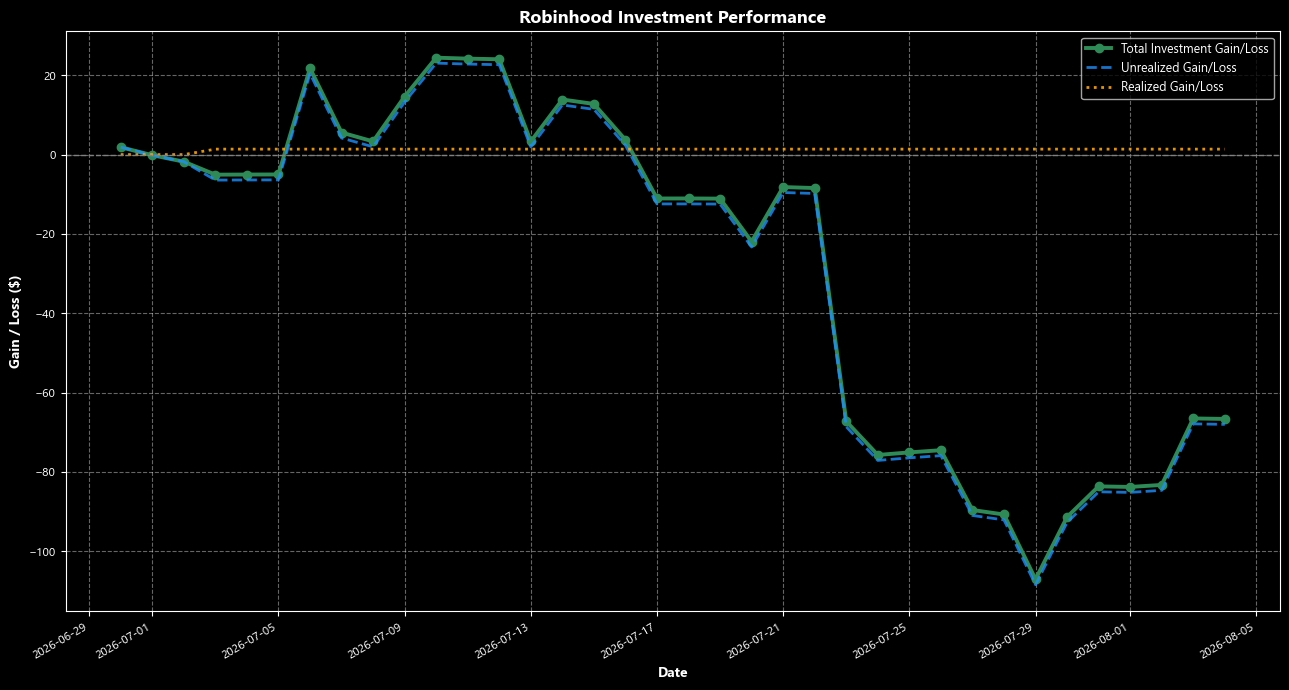

Robinhood Investment Performance Summary
-------------------------------------------------------
Date: 2026-08-04
Realized Gain/Loss: $1.37
Unrealized Gain/Loss: $-68.00
Total Investment Gain/Loss: $-66.63

Current Holdings:
-------------------------------------------------------
NVDA: 1.000000 shares/units | Cost Basis: $197.90
ETH-USD: 0.000872 shares/units | Cost Basis: $1.39
TSLA: 1.000000 shares/units | Cost Basis: $397.00
DOGE-USD: 297.880000 shares/units | Cost Basis: $23.00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# =========================
# File path
# =========================
file_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\RobinhoodTracker.xlsx"

# =========================
# Load data
# =========================
df = pd.read_excel(file_path)

# =========================
# Clean data
# =========================
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Transaction"] = df["Transaction"].astype(str).str.strip()
df["AssetType"] = df["AssetType"].astype(str).str.strip()
df["AssetName"] = df["AssetName"].astype(str).str.strip()
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

df = df.dropna(subset=["Date", "Transaction", "AssetName", "Quantity", "Amount"])

# Remove time portion
df["Date"] = df["Date"].dt.normalize()

# =========================
# Map your asset names to market tickers
# Update this as you add more assets
# =========================
ticker_map = {
    "Nvidia": "NVDA",
    "Tesla": "TSLA",
    "Sony": "SONY",
    "Ethereum": "ETH-USD",
    "Doge": "DOGE-USD",
    "Dogecoin": "DOGE-USD"
}

# Add ticker column
df["Ticker"] = df["AssetName"].map(ticker_map)

# Keep only rows with mapped tickers or relevant non-market transactions
market_df = df.dropna(subset=["Ticker"]).copy()

if market_df.empty:
    raise ValueError("No matching tickers found. Update ticker_map with your AssetName values.")

# =========================
# Date range
# =========================
start_date = market_df["Date"].min()
end_date = pd.Timestamp.today().normalize()

# If your worksheet has future dates, use latest transaction date instead
if market_df["Date"].max() > end_date:
    end_date = market_df["Date"].max()

date_range = pd.date_range(start_date, end_date, freq="D")

# =========================
# Download market prices
# =========================
tickers = sorted(market_df["Ticker"].unique())

price_data = yf.download(
    tickers,
    start=start_date - pd.Timedelta(days=5),
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False
)

# Handle single ticker vs multiple tickers
if len(tickers) == 1:
    close_prices = price_data[["Close"]].copy()
    close_prices.columns = tickers
else:
    close_prices = price_data["Close"].copy()

# Reindex to every calendar day and forward-fill missing market days
close_prices = close_prices.reindex(date_range).ffill()

# =========================
# Portfolio accounting
# This tracks gain/loss, not account value
# =========================
holdings = {}
cost_basis = {}
realized_gain_loss = 0

records = []

# Sort transactions by date
market_df = market_df.sort_values("Date")

for current_date in date_range:
    todays_transactions = market_df[market_df["Date"] == current_date]

    for _, row in todays_transactions.iterrows():
        transaction = row["Transaction"].lower()
        ticker = row["Ticker"]
        quantity = row["Quantity"]
        amount = row["Amount"]

        if ticker not in holdings:
            holdings[ticker] = 0
            cost_basis[ticker] = 0

        if transaction == "buy":
            # Buying does NOT create gain.
            # It only increases shares and cost basis.
            buy_cost = abs(amount)

            holdings[ticker] += quantity
            cost_basis[ticker] += buy_cost

        elif transaction == "sell":
            # Selling realizes gain/loss.
            sell_proceeds = abs(amount)

            if holdings[ticker] > 0:
                avg_cost_per_share = cost_basis[ticker] / holdings[ticker]

                quantity_sold = min(quantity, holdings[ticker])
                cost_removed = avg_cost_per_share * quantity_sold

                realized_gain_loss += sell_proceeds - cost_removed

                holdings[ticker] -= quantity_sold
                cost_basis[ticker] -= cost_removed

                # Avoid tiny floating point leftovers
                if holdings[ticker] < 0.0000001:
                    holdings[ticker] = 0
                    cost_basis[ticker] = 0

        elif transaction in ["dividend", "interest"]:
            # Dividends/interest count as realized investment income
            realized_gain_loss += abs(amount)

        elif transaction == "fee":
            # Fees reduce investment performance
            realized_gain_loss -= abs(amount)

        # Deposits and withdrawals are intentionally ignored here.
        # They affect account value, but not investment performance.

    # Calculate unrealized gain/loss for current holdings
    unrealized_gain_loss = 0

    for ticker in holdings:
        shares = holdings[ticker]
        basis = cost_basis[ticker]

        if shares > 0:
            try:
                current_price = close_prices.loc[current_date, ticker]
                current_market_value = shares * current_price
                unrealized_gain_loss += current_market_value - basis
            except Exception:
                pass

    total_gain_loss = realized_gain_loss + unrealized_gain_loss

    records.append({
        "Date": current_date,
        "RealizedGainLoss": realized_gain_loss,
        "UnrealizedGainLoss": unrealized_gain_loss,
        "TotalGainLoss": total_gain_loss
    })

performance_df = pd.DataFrame(records)

# =========================
# Plot graph
# =========================
plt.figure(figsize=(13, 7))

plt.plot(
    performance_df["Date"],
    performance_df["TotalGainLoss"],
    linewidth=2.8,
    marker="o",
    color="seagreen",
    label="Total Investment Gain/Loss"
)

plt.plot(
    performance_df["Date"],
    performance_df["UnrealizedGainLoss"],
    linewidth=2,
    linestyle="--",
    color="dodgerblue",
    alpha=0.8,
    label="Unrealized Gain/Loss"
)

plt.plot(
    performance_df["Date"],
    performance_df["RealizedGainLoss"],
    linewidth=2,
    linestyle=":",
    color="orange",
    alpha=0.9,
    label="Realized Gain/Loss"
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.title("Robinhood Investment Performance")
plt.xlabel("Date")
plt.ylabel("Gain / Loss ($)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

# =========================
# Console summary
# =========================
latest = performance_df.iloc[-1]

print("Robinhood Investment Performance Summary")
print("-" * 55)
print(f"Date: {latest['Date'].strftime('%Y-%m-%d')}")
print(f"Realized Gain/Loss: ${latest['RealizedGainLoss']:,.2f}")
print(f"Unrealized Gain/Loss: ${latest['UnrealizedGainLoss']:,.2f}")
print(f"Total Investment Gain/Loss: ${latest['TotalGainLoss']:,.2f}")

print("\nCurrent Holdings:")
print("-" * 55)

for ticker in holdings:
    if holdings[ticker] > 0:
        print(f"{ticker}: {holdings[ticker]:,.6f} shares/units | Cost Basis: ${cost_basis[ticker]:,.2f}")

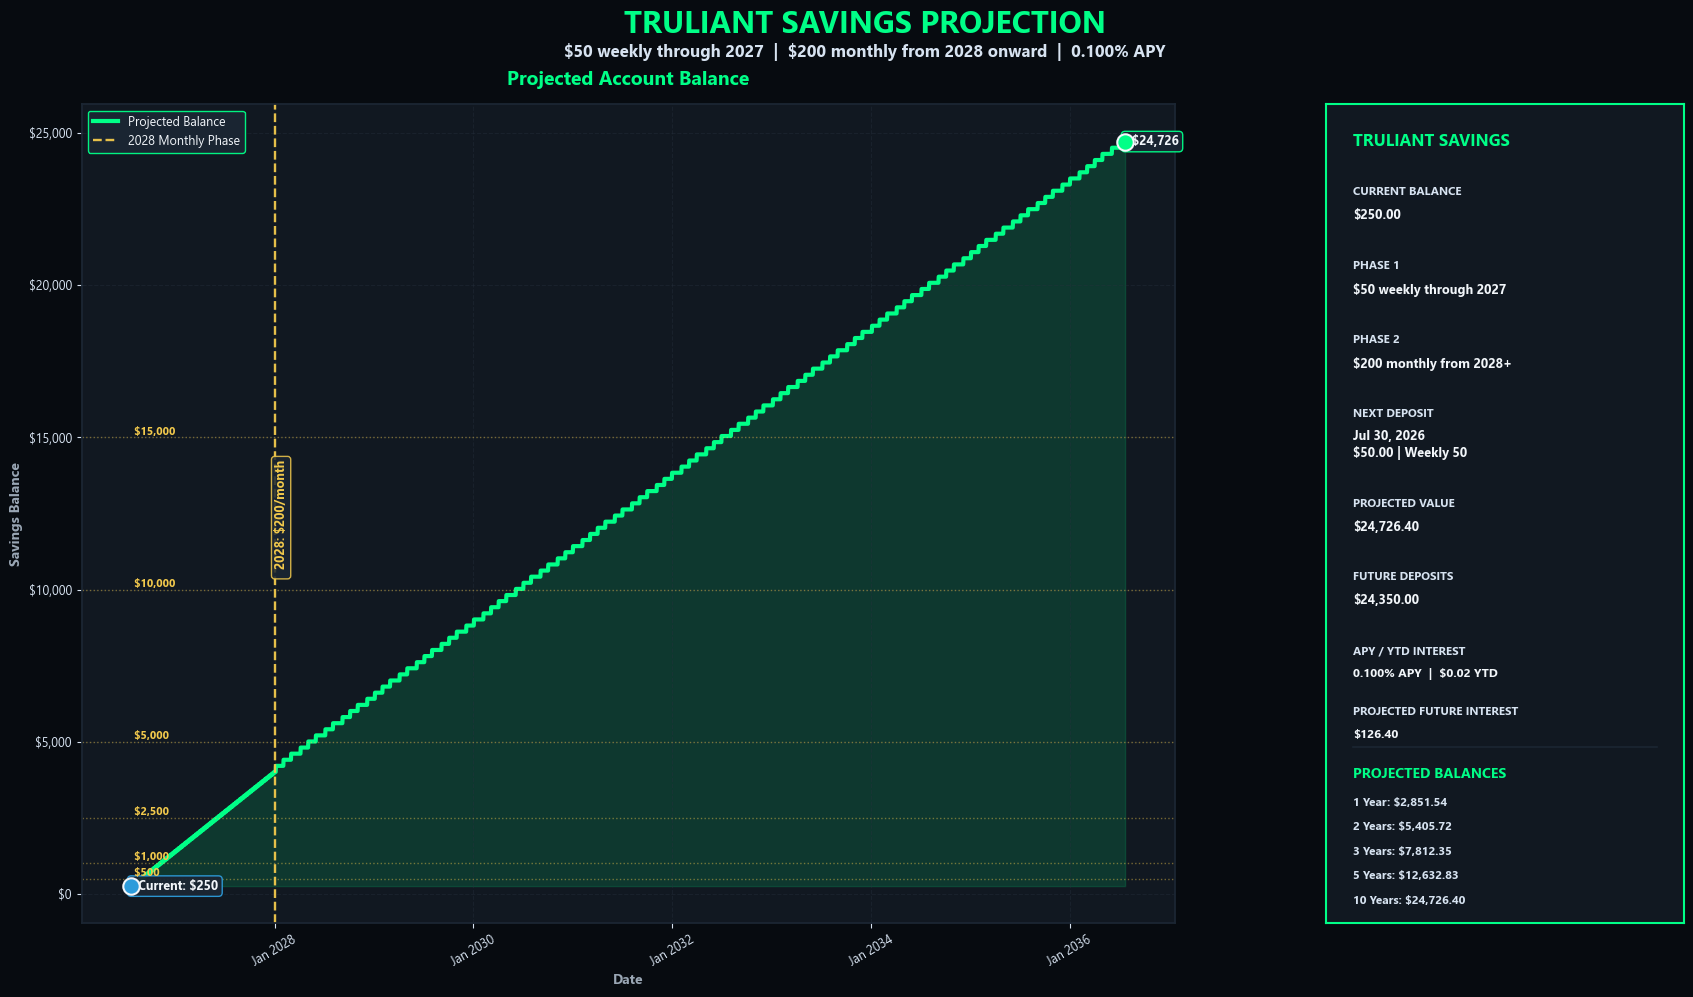

Truliant savings projection saved to: C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\TruliantSavingsProjection_50Weekly_200Monthly.png

Truliant Savings Projection Summary
-----------------------------------------------------------------
Current Balance: $250.00
Phase 1: $50.00 weekly through 2027-12-31
Phase 2: $200.00 monthly starting 2028-01-01
Monthly Deposit Rule: First Thursday of each month
Projection Years: 10
APY: 0.100%
YTD Interest: $0.02
-----------------------------------------------------------------
Next Deposit Date: 2026-07-30
Next Deposit Amount: $50.00
Next Deposit Type: Weekly 50
-----------------------------------------------------------------
Weekly Phase Future Deposits: $3,750.00
Monthly Phase Future Deposits: $20,600.00
Total Future Deposits: $24,350.00
Projected Future Interest Earned: $126.40
Projected Ending Balance: $24,726.40
-----------------------------------------------------------------

Projected Balances:
1 Year: $2,851.54


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# =========================
# Truliant Savings Projection Settings
# =========================
CURRENT_BALANCE = 250.00

# Phase 1: Weekly savings
WEEKLY_DEPOSIT = 50.00
WEEKLY_DEPOSIT_WEEKDAY = 3          # Monday=0, Tuesday=1, Wednesday=2, Thursday=3
WEEKLY_PHASE_END = "2027-12-31"

# Phase 2: Monthly savings
MONTHLY_DEPOSIT = 200.00
MONTHLY_PHASE_START = "2028-01-01"
MONTHLY_DEPOSIT_WEEKDAY = 3         # First Thursday of each month

# Projection length
PROJECTION_YEARS = 10

# Truliant APY / interest info
ANNUAL_APY = 0.001                  # 0.100% APY = 0.001 as a decimal
YTD_INTEREST = 0.02                 # Current YTD interest earned

output_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\TruliantSavingsProjection_50Weekly_200Monthly.png"

# =========================
# EA Companion-style theme
# =========================
BG = "#070B10"
PANEL = "#111821"
PANEL_2 = "#1B2633"
TEXT = "#F2F6FA"
LABEL_TEXT = "#D7E3F1"
MUTED = "#9AA7B5"
GREEN = "#00FF87"
BLUE = "#2D9CDB"
YELLOW = "#F2C94C"
GRID = "#26313D"

plt.style.use("dark_background")

plt.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "text.usetex": False,
})

# =========================
# Date setup
# =========================
today = pd.Timestamp.today().normalize()
projection_end_date = today + pd.DateOffset(years=PROJECTION_YEARS)

weekly_phase_end = pd.to_datetime(WEEKLY_PHASE_END).normalize()
monthly_phase_start = pd.to_datetime(MONTHLY_PHASE_START).normalize()

# =========================
# Helper functions
# =========================
def get_next_weekday_after(current_date, weekday):
    """
    Returns the next requested weekday strictly after current_date.
    Monday=0, Sunday=6.
    """
    days_until = weekday - current_date.weekday()

    if days_until <= 0:
        days_until += 7

    return current_date + pd.Timedelta(days=days_until)


def first_weekday_of_month(year, month, weekday):
    """
    Returns the first selected weekday of a month.
    Example: first Thursday of January.
    Monday=0, Sunday=6.
    """
    first_day = pd.Timestamp(year=year, month=month, day=1)
    days_until = weekday - first_day.weekday()

    if days_until < 0:
        days_until += 7

    return first_day + pd.Timedelta(days=days_until)


def build_monthly_deposit_dates(start_date, end_date, weekday):
    """
    Builds monthly deposit dates on the first selected weekday of each month.
    """
    dates = []

    month_starts = pd.date_range(
        start=start_date.replace(day=1),
        end=end_date,
        freq="MS"
    )

    for month_start in month_starts:
        deposit_date = first_weekday_of_month(
            month_start.year,
            month_start.month,
            weekday
        )

        if start_date <= deposit_date <= end_date:
            dates.append(deposit_date)

    return pd.to_datetime(dates)


def style_axis(ax, title):
    ax.set_facecolor(PANEL)

    ax.set_title(
        title,
        color=GREEN,
        fontsize=14,
        fontweight="bold",
        pad=14
    )

    ax.tick_params(colors=LABEL_TEXT)

    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

    ax.grid(True, color=GRID, linestyle="--", alpha=0.40)

    for spine in ax.spines.values():
        spine.set_color(PANEL_2)
        spine.set_linewidth(1.3)


def dollar_formatter(x, pos):
    return f"${x:,.0f}"


def style_legend(legend, edge_color=GREEN):
    if legend:
        legend.get_frame().set_facecolor(PANEL_2)
        legend.get_frame().set_edgecolor(edge_color)
        legend.get_frame().set_alpha(0.95)

        for text in legend.get_texts():
            text.set_color(TEXT)


def get_balance_near_date(df, target_date):
    closest_row = df.iloc[
        (df["Date"] - target_date).abs().argsort()[:1]
    ]

    return closest_row.iloc[0]["Balance"]


def money_text(value, decimals=2):
    """
    Escapes dollar signs for matplotlib text.
    """
    return f"\\${value:,.{decimals}f}"


def add_card_line(ax, text, x, y, color=TEXT, fontsize=9.5, weight="bold"):
    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        color=color,
        fontsize=fontsize,
        fontweight=weight,
        clip_on=True
    )


def add_card_pair(ax, label, value, x, y, label_size=8.4, value_size=9.2):
    add_card_line(
        ax,
        label.upper(),
        x,
        y,
        color=LABEL_TEXT,
        fontsize=label_size
    )

    add_card_line(
        ax,
        value,
        x,
        y - 0.028,
        color=TEXT,
        fontsize=value_size
    )


# =========================
# Build deposit schedules
# =========================

# Weekly deposits: $50 every Thursday through 2027
weekly_start_date = get_next_weekday_after(today, WEEKLY_DEPOSIT_WEEKDAY)

if weekly_start_date <= weekly_phase_end and weekly_start_date <= projection_end_date:
    weekly_deposit_dates = pd.date_range(
        start=weekly_start_date,
        end=min(weekly_phase_end, projection_end_date),
        freq="7D"
    )
else:
    weekly_deposit_dates = pd.to_datetime([])

# Monthly deposits: $200/month starting 2028
monthly_start_for_schedule = max(monthly_phase_start, today)

if monthly_start_for_schedule <= projection_end_date:
    monthly_deposit_dates = build_monthly_deposit_dates(
        monthly_start_for_schedule,
        projection_end_date,
        MONTHLY_DEPOSIT_WEEKDAY
    )
else:
    monthly_deposit_dates = pd.to_datetime([])

weekly_deposit_set = set(weekly_deposit_dates)
monthly_deposit_set = set(monthly_deposit_dates)

# =========================
# Projection calculation
# =========================
date_range = pd.date_range(today, projection_end_date, freq="D")

daily_rate = (1 + ANNUAL_APY) ** (1 / 365) - 1 if ANNUAL_APY > 0 else 0

records = []

balance = CURRENT_BALANCE
total_deposited = 0.0
future_interest_earned = 0.0

for current_date in date_range:
    deposit_today = 0.0
    deposit_type = "None"

    if current_date in weekly_deposit_set:
        deposit_today = WEEKLY_DEPOSIT
        deposit_type = "Weekly 50"

    elif current_date in monthly_deposit_set:
        deposit_today = MONTHLY_DEPOSIT
        deposit_type = "Monthly 200"

    if deposit_today > 0:
        balance += deposit_today
        total_deposited += deposit_today

    if daily_rate > 0:
        daily_interest = balance * daily_rate
        balance += daily_interest
        future_interest_earned += daily_interest

    records.append({
        "Date": current_date,
        "Balance": balance,
        "Deposit": deposit_today,
        "DepositType": deposit_type,
        "TotalDeposited": total_deposited,
        "FutureInterestEarned": future_interest_earned
    })

savings_df = pd.DataFrame(records)

latest_row = savings_df.iloc[-1]
projected_balance = latest_row["Balance"]

deposit_df = savings_df[savings_df["Deposit"] > 0].copy()

weekly_total = deposit_df[deposit_df["DepositType"] == "Weekly 50"]["Deposit"].sum()
monthly_total = deposit_df[deposit_df["DepositType"] == "Monthly 200"]["Deposit"].sum()
total_future_deposits = deposit_df["Deposit"].sum()

# =========================
# Milestone calculations
# =========================
milestones = [500, 1000, 2500, 5000, 10000, 15000, 25000, 50000]

milestone_results = {}

for milestone in milestones:
    reached = savings_df[savings_df["Balance"] >= milestone]

    if not reached.empty:
        milestone_results[milestone] = reached.iloc[0]["Date"]
    else:
        milestone_results[milestone] = None

# =========================
# Yearly balance estimates
# =========================
yearly_balance_lines = []

for year_num in range(1, PROJECTION_YEARS + 1):
    target_date = today + pd.DateOffset(years=year_num)
    balance_at_year = get_balance_near_date(savings_df, target_date)

    yearly_balance_lines.append({
        "Year": year_num,
        "Balance": balance_at_year
    })

# =========================
# Selected projected balance values for dashboard card
# =========================
selected_years = [1, 2, 3, 5, 10]
selected_year_balances = {}

for year_num in selected_years:
    if year_num <= PROJECTION_YEARS:
        target_date = today + pd.DateOffset(years=year_num)
        selected_year_balances[year_num] = get_balance_near_date(
            savings_df,
            target_date
        )

# =========================
# Next deposit details
# =========================
future_deposits = deposit_df[deposit_df["Date"] > today].copy()

if not future_deposits.empty:
    next_deposit_row = future_deposits.iloc[0]
    next_deposit_date = next_deposit_row["Date"]
    next_deposit_amount = next_deposit_row["Deposit"]
    next_deposit_type = next_deposit_row["DepositType"]
else:
    next_deposit_date = None
    next_deposit_amount = 0
    next_deposit_type = "None"

# =========================
# Plot dashboard
# =========================
fig = plt.figure(figsize=(18, 10.5), facecolor=BG)

fig.suptitle(
    "TRULIANT SAVINGS PROJECTION",
    fontsize=22,
    fontweight="bold",
    color=GREEN,
    y=0.965
)

fig.text(
    0.5,
    0.925,
    "\\$50 weekly through 2027  |  \\$200 monthly from 2028 onward  |  0.100% APY",
    ha="center",
    va="center",
    color=LABEL_TEXT,
    fontsize=12,
    fontweight="bold"
)

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.45, 1.45, 1.10],
    wspace=0.35
)

# =========================
# Main balance projection chart
# =========================
ax1 = fig.add_subplot(gs[0, :2])
style_axis(ax1, "Projected Account Balance")

ax1.plot(
    savings_df["Date"],
    savings_df["Balance"],
    color=GREEN,
    linewidth=3,
    label="Projected Balance"
)

ax1.fill_between(
    savings_df["Date"],
    savings_df["Balance"],
    CURRENT_BALANCE,
    color=GREEN,
    alpha=0.14
)

# Current balance marker
ax1.scatter(
    today,
    CURRENT_BALANCE,
    s=140,
    color=BLUE,
    edgecolor=TEXT,
    linewidth=1.5,
    zorder=5
)

ax1.text(
    today,
    CURRENT_BALANCE,
    f"  Current: {money_text(CURRENT_BALANCE, 0)}",
    color=TEXT,
    fontsize=9,
    fontweight="bold",
    va="center",
    bbox=dict(
        facecolor=PANEL_2,
        edgecolor=BLUE,
        boxstyle="round,pad=0.3",
        alpha=0.95
    )
)

# Final projected value marker
ax1.scatter(
    latest_row["Date"],
    latest_row["Balance"],
    s=140,
    color=GREEN,
    edgecolor=TEXT,
    linewidth=1.5,
    zorder=5
)

ax1.text(
    latest_row["Date"],
    latest_row["Balance"],
    f"  {money_text(latest_row['Balance'], 0)}",
    color=TEXT,
    fontsize=9,
    fontweight="bold",
    va="center",
    bbox=dict(
        facecolor=PANEL_2,
        edgecolor=GREEN,
        boxstyle="round,pad=0.3",
        alpha=0.95
    )
)

# Phase change marker
if today <= monthly_phase_start <= projection_end_date:
    ax1.axvline(
        monthly_phase_start,
        color=YELLOW,
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label="2028 Monthly Phase"
    )

    ax1.text(
        monthly_phase_start,
        projected_balance * 0.50,
        "  2028: \\$200/month",
        color=YELLOW,
        fontsize=9,
        fontweight="bold",
        rotation=90,
        va="center",
        bbox=dict(
            facecolor=PANEL_2,
            edgecolor=YELLOW,
            boxstyle="round,pad=0.25",
            alpha=0.85
        )
    )

# Milestone horizontal lines
for milestone in milestones:
    if milestone <= projected_balance:
        ax1.axhline(
            milestone,
            color=YELLOW,
            linestyle=":",
            linewidth=1,
            alpha=0.45
        )

        ax1.text(
            today,
            milestone,
            f" {money_text(milestone, 0)}",
            color=YELLOW,
            fontsize=8,
            va="bottom",
            fontweight="bold"
        )

ax1.set_xlabel("Date")
ax1.set_ylabel("Savings Balance")
ax1.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.tick_params(axis="x", rotation=30)

legend1 = ax1.legend(loc="upper left", frameon=True)
style_legend(legend1)

# =========================
# Summary card
# =========================
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PANEL)
ax2.set_xticks([])
ax2.set_yticks([])

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color(GREEN)
    spine.set_linewidth(1.5)

if next_deposit_date is not None:
    next_deposit_short = (
        f"{next_deposit_date.strftime('%b %d, %Y')}\n"
        f"{money_text(next_deposit_amount)} | {next_deposit_type}"
    )
else:
    next_deposit_short = "No future deposits"

# =========================
# Summary card layout
# =========================
x = 0.075

add_card_line(
    ax2,
    "TRULIANT SAVINGS",
    x,
    0.965,
    color=GREEN,
    fontsize=12.0
)

add_card_pair(
    ax2,
    "Current Balance",
    money_text(CURRENT_BALANCE),
    x,
    0.900
)

add_card_pair(
    ax2,
    "Phase 1",
    f"{money_text(WEEKLY_DEPOSIT, 0)} weekly through 2027",
    x,
    0.810
)

add_card_pair(
    ax2,
    "Phase 2",
    f"{money_text(MONTHLY_DEPOSIT, 0)} monthly from 2028+",
    x,
    0.720
)

add_card_pair(
    ax2,
    "Next Deposit",
    next_deposit_short,
    x,
    0.630
)

add_card_pair(
    ax2,
    "Projected Value",
    money_text(projected_balance),
    x,
    0.520
)

add_card_pair(
    ax2,
    "Future Deposits",
    money_text(total_future_deposits),
    x,
    0.430
)

add_card_pair(
    ax2,
    "APY / YTD Interest",
    f"{ANNUAL_APY * 100:.3f}% APY  |  {money_text(YTD_INTEREST)} YTD",
    x,
    0.340,
    value_size=8.8
)

add_card_pair(
    ax2,
    "Projected Future Interest",
    money_text(latest_row["FutureInterestEarned"]),
    x,
    0.265,
    value_size=8.8
)

# Divider
ax2.plot(
    [0.075, 0.925],
    [0.215, 0.215],
    transform=ax2.transAxes,
    color=PANEL_2,
    linewidth=1.2
)

# Projected balances section
add_card_line(
    ax2,
    "PROJECTED BALANCES",
    x,
    0.190,
    color=GREEN,
    fontsize=10.2
)

balance_y_positions = {
    1: 0.155,
    2: 0.125,
    3: 0.095,
    5: 0.065,
    10: 0.035
}

for year_num, y_pos in balance_y_positions.items():
    if year_num in selected_year_balances:
        add_card_line(
            ax2,
            f"{year_num} Year{'s' if year_num > 1 else ''}: "
            f"{money_text(selected_year_balances[year_num])}",
            x,
            y_pos,
            color=LABEL_TEXT,
            fontsize=8.5
        )

# =========================
# Save and show
# =========================
plt.subplots_adjust(
    top=0.875,
    bottom=0.095,
    left=0.065,
    right=0.955
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

# =========================
# Console summary
# =========================
print(f"Truliant savings projection saved to: {output_path}")
print()
print("Truliant Savings Projection Summary")
print("-" * 65)
print(f"Current Balance: ${CURRENT_BALANCE:,.2f}")
print(f"Phase 1: ${WEEKLY_DEPOSIT:,.2f} weekly through {weekly_phase_end.strftime('%Y-%m-%d')}")
print(f"Phase 2: ${MONTHLY_DEPOSIT:,.2f} monthly starting {monthly_phase_start.strftime('%Y-%m-%d')}")
print("Monthly Deposit Rule: First Thursday of each month")
print(f"Projection Years: {PROJECTION_YEARS}")
print(f"APY: {ANNUAL_APY * 100:.3f}%")
print(f"YTD Interest: ${YTD_INTEREST:,.2f}")
print("-" * 65)

if next_deposit_date is not None:
    print(f"Next Deposit Date: {next_deposit_date.strftime('%Y-%m-%d')}")
    print(f"Next Deposit Amount: ${next_deposit_amount:,.2f}")
    print(f"Next Deposit Type: {next_deposit_type}")

print("-" * 65)
print(f"Weekly Phase Future Deposits: ${weekly_total:,.2f}")
print(f"Monthly Phase Future Deposits: ${monthly_total:,.2f}")
print(f"Total Future Deposits: ${total_future_deposits:,.2f}")
print(f"Projected Future Interest Earned: ${latest_row['FutureInterestEarned']:,.2f}")
print(f"Projected Ending Balance: ${projected_balance:,.2f}")
print("-" * 65)

print("\nProjected Balances:")
for row in yearly_balance_lines:
    print(f"{row['Year']} Year{'s' if row['Year'] > 1 else ''}: ${row['Balance']:,.2f}")

print("\nMilestones:")
for milestone, date_hit in milestone_results.items():
    if date_hit is not None:
        print(f"${milestone:,.0f}: {date_hit.strftime('%Y-%m-%d')}")
    else:
        print(f"${milestone:,.0f}: Not reached within projection period")

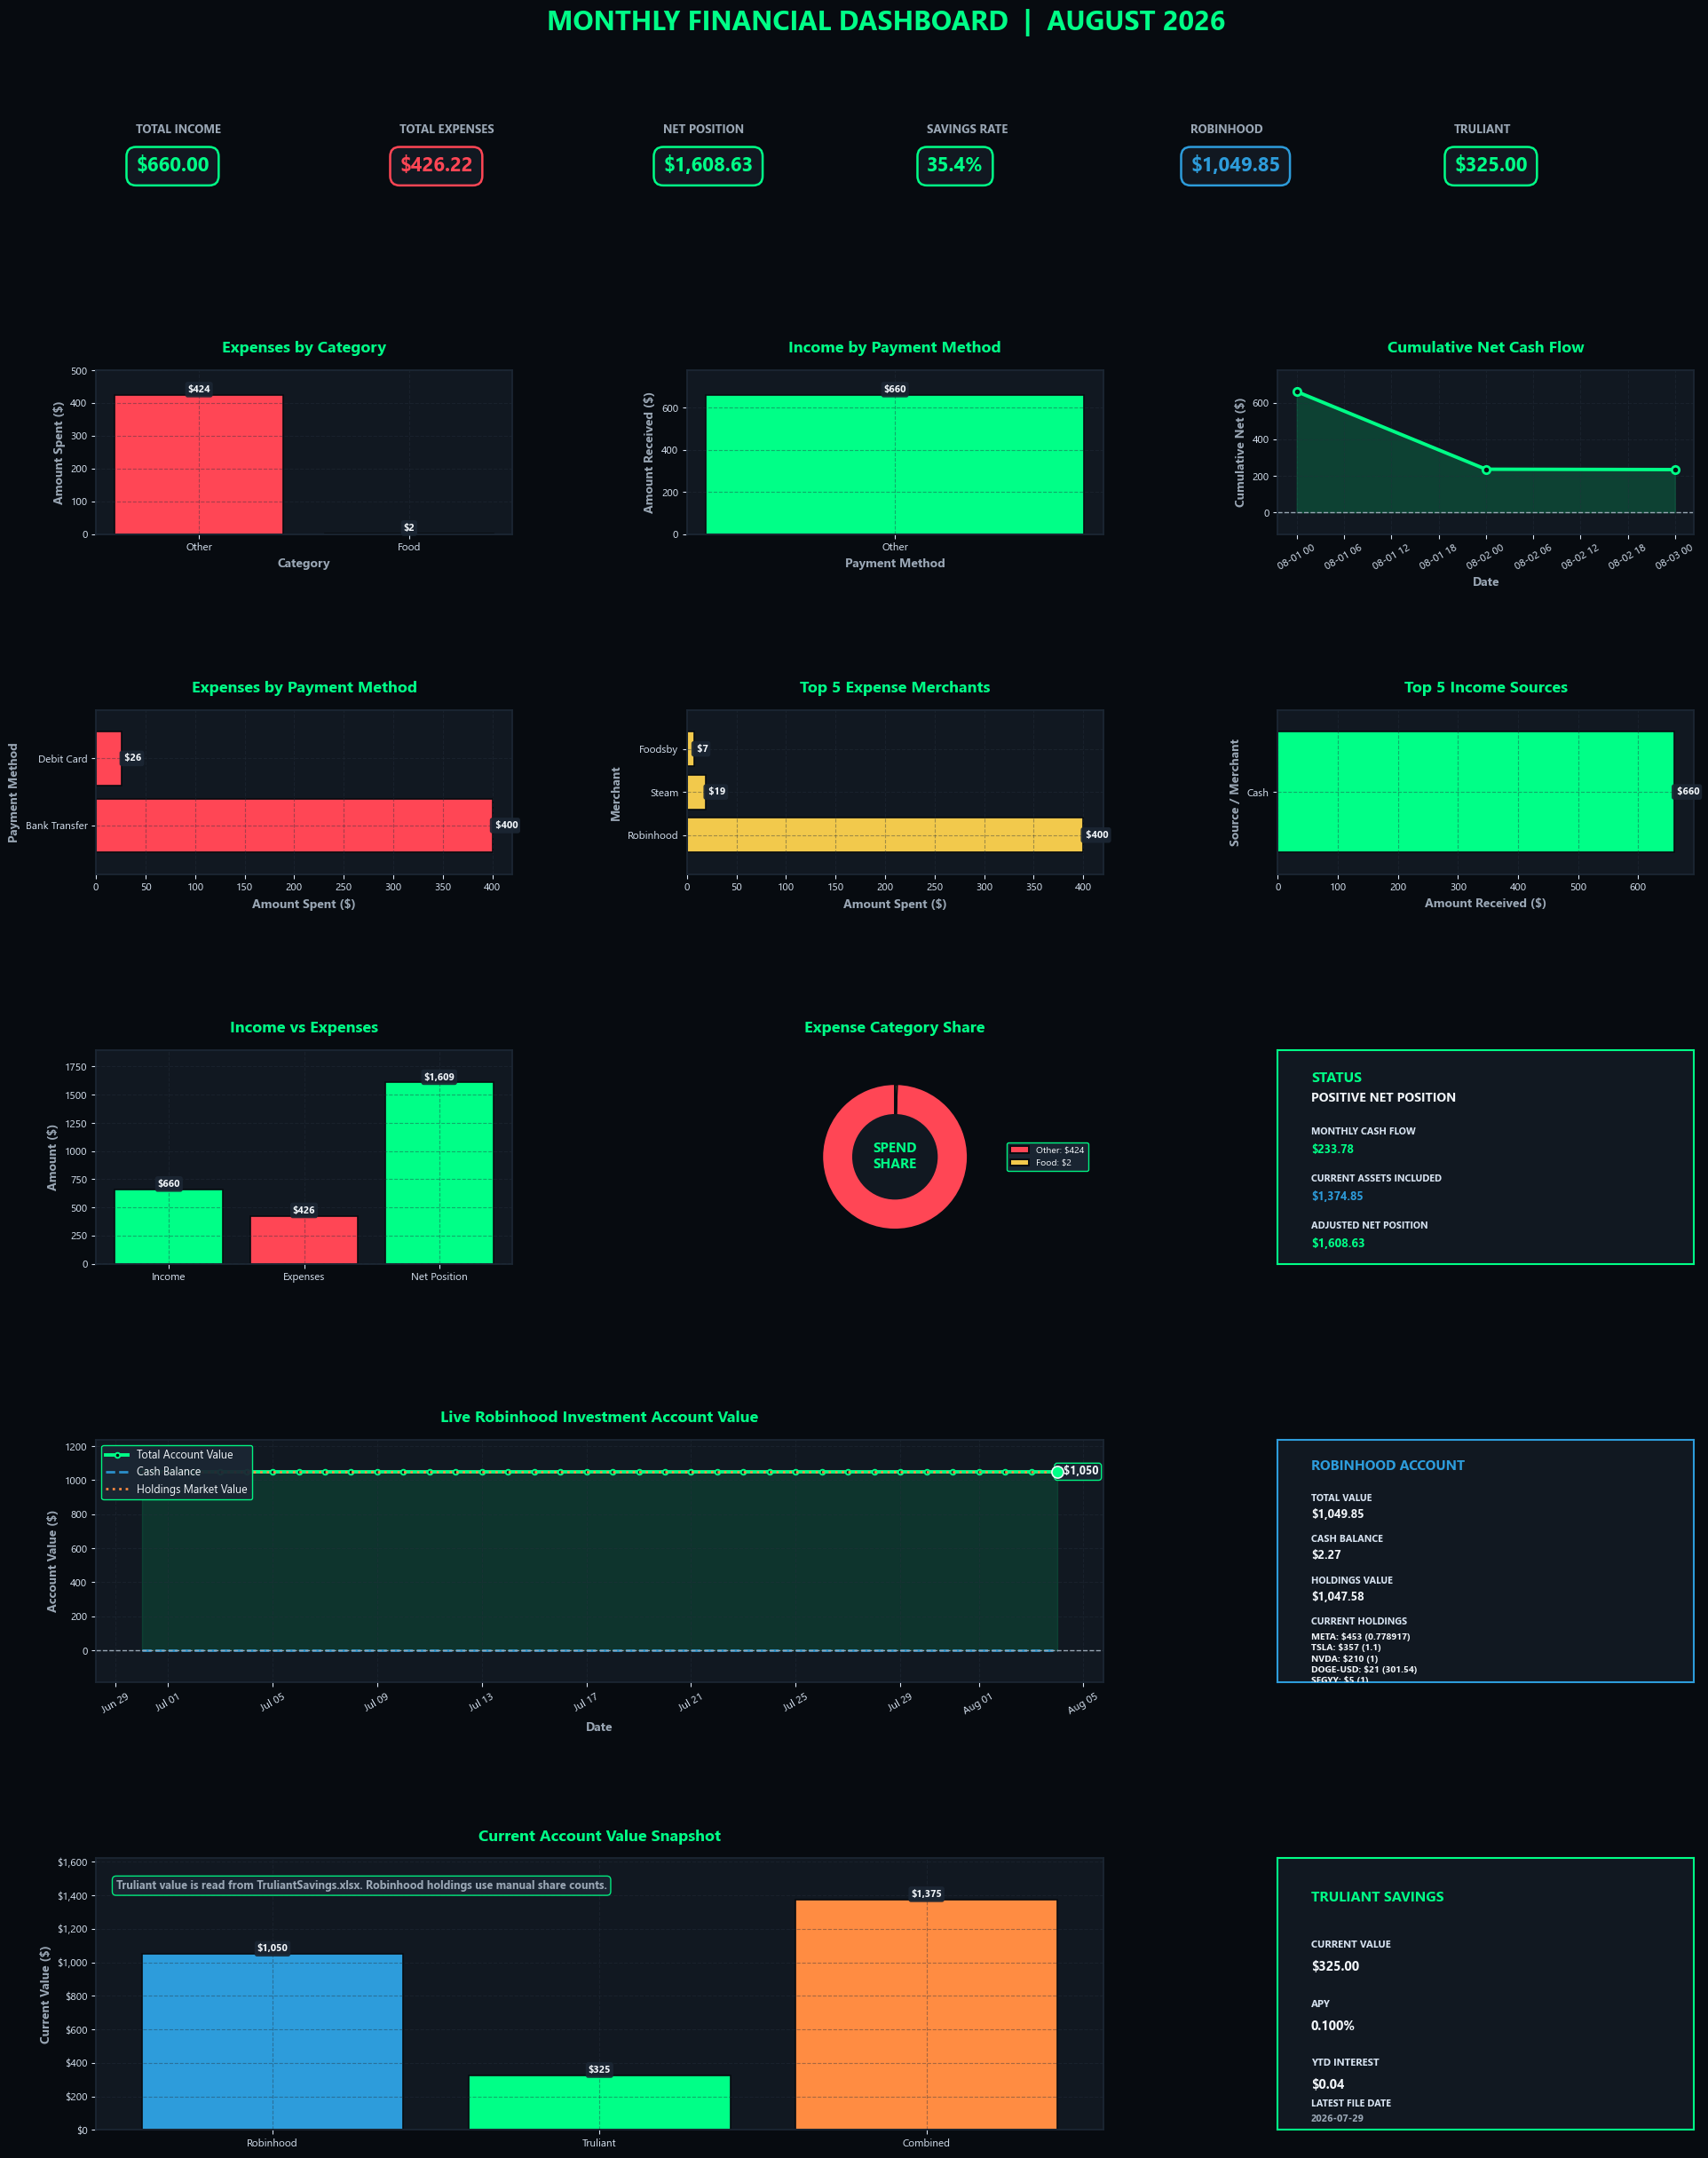

Dashboard saved to: C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\MonthlyDashboard_EAStyle.png

Monthly Financial Summary - August 2026
-------------------------------------------------------
Total Income: $660.00
Total Expenses: $426.22
Monthly Cash Flow Only: $233.78
Robinhood Current Value: $1,049.85
Truliant Current Value: $325.00
Combined Current Assets: $1,374.85
Asset-Adjusted Net Position: $1,608.63
Savings Rate: 35.4%
-------------------------------------------------------

Expenses by Category:
Category
Other    424.35
Food       1.87
Name: Amount, dtype: float64

Income by Payment Method:
PaymentMethod
Other    660.0
Name: Amount, dtype: float64

Top Expense Merchants:
Merchant
Robinhood    400.00
Steam         19.20
Foodsby        7.02
Name: Amount, dtype: float64

Top Income Sources:
Merchant
Cash    660.0
Name: Amount, dtype: float64

Robinhood Investment Account Summary:
-------------------------------------------------------
Estimated Total A

In [27]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["CURL_CA_BUNDLE"] = certifi.where()

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap
import yfinance as yf
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter


# =========================
# File paths
# =========================
expense_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\ExpenseTracker.xlsx"
cashflow_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\Cashflow.xlsx"
robinhood_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\RobinhoodTracker.xlsx"
truliant_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\TruliantSavings.xlsx"

output_path = r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\MonthlyDashboard_EAStyle.png"


# =========================
# Truliant known values
# =========================
TRULIANT_ACCOUNT_NAME = "Truliant Savings"
TRULIANT_APY_PERCENT = 0.100
TRULIANT_YTD_INTEREST = 0.04
TRULIANT_FALLBACK_VALUE = 250.00


# =========================
# Manual Robinhood holdings
# These override calculated transaction quantities.
# =========================
MANUAL_ROBINHOOD_HOLDINGS = {
    "DOGE-USD": 301.54,
    "ETH-USD": 0.000872,
    "TSLA": 1.10,
    "NVDA": 1.0,
    "SFGYY": 1.0,
    "META": 0.778917,
}

# Optional manual cash override.
# Leave as None to calculate Robinhood cash from the Excel transactions.
# If your dashboard cash is off, set this to the exact Robinhood cash/buying power.
MANUAL_ROBINHOOD_CASH_BALANCE = None


# =========================
# EA Companion-style theme
# =========================
BG = "#070B10"
PANEL = "#111821"
PANEL_2 = "#1B2633"
TEXT = "#F2F6FA"
LABEL_TEXT = "#D7E3F1"
MUTED = "#9AA7B5"
GREEN = "#00FF87"
GREEN_DARK = "#00C46A"
RED = "#FF4655"
BLUE = "#2D9CDB"
YELLOW = "#F2C94C"
PURPLE = "#9B51E0"
ORANGE = "#FF8C42"
GRID = "#26313D"

plt.style.use("dark_background")

plt.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 9,
    "text.usetex": False,
})


# =========================
# General helper functions
# =========================
def money_text(value, decimals=2):
    try:
        return f"${float(value):,.{decimals}f}"
    except Exception:
        return f"$0.{''.join(['0'] * decimals)}"


def dollar_formatter(x, pos):
    return f"${x:,.0f}"


def clean_money_series(series):
    """
    Converts Excel-looking values into numbers.
    Handles:
    $1,000.00
    1,000.00
    -197.90
    (197.90)
    """
    s = series.astype(str).str.strip()
    s = s.str.replace("\u2212", "-", regex=False)

    parentheses_negative = s.str.match(r"^\(.*\)$", na=False)

    s = s.str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("(", "", regex=False)
    s = s.str.replace(")", "", regex=False)

    out = pd.to_numeric(s, errors="coerce")
    out.loc[parentheses_negative] = -out.loc[parentheses_negative].abs()

    return out


def clean_col_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def find_column(df, possible_names):
    normalized_cols = {clean_col_name(col): col for col in df.columns}

    for name in possible_names:
        clean_name = clean_col_name(name)

        if clean_name in normalized_cols:
            return normalized_cols[clean_name]

    return None


def format_shares(shares):
    try:
        shares = float(shares)

        if abs(shares) < 1:
            return f"{shares:,.8f}".rstrip("0").rstrip(".")

        if shares % 1 != 0:
            return f"{shares:,.6f}".rstrip("0").rstrip(".")

        return f"{shares:,.0f}"

    except Exception:
        return str(shares)


def style_axis(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=GREEN, fontsize=13, fontweight="bold", pad=14)
    ax.tick_params(colors=LABEL_TEXT, labelsize=8.5)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.grid(True, color=GRID, linestyle="--", alpha=0.40)

    for spine in ax.spines.values():
        spine.set_color(PANEL_2)
        spine.set_linewidth(1.3)

    ax.margins(y=0.18)


def add_card_line(ax, text, x, y, color=TEXT, fontsize=9.5, weight="bold"):
    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        color=color,
        fontsize=fontsize,
        fontweight=weight,
        clip_on=True
    )


def add_bar_labels_vertical(ax, bars, color=TEXT, decimals=0):
    for bar in bars:
        height = bar.get_height()
        va = "bottom" if height >= 0 else "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            money_text(height, decimals),
            ha="center",
            va=va,
            color=color,
            fontsize=8,
            fontweight="bold",
            bbox=dict(
                facecolor=PANEL_2,
                edgecolor="none",
                boxstyle="round,pad=0.25",
                alpha=0.92
            )
        )


def add_bar_labels_horizontal(ax, bars, color=TEXT, decimals=0):
    for bar in bars:
        width = bar.get_width()

        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {money_text(width, decimals)}",
            va="center",
            color=color,
            fontsize=8,
            fontweight="bold",
            bbox=dict(
                facecolor=PANEL_2,
                edgecolor="none",
                boxstyle="round,pad=0.25",
                alpha=0.92
            )
        )


def wrap_x_labels(ax, width=12):
    labels = []

    for label in ax.get_xticklabels():
        labels.append(textwrap.fill(label.get_text(), width))

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, rotation=0, ha="center", color=LABEL_TEXT)


def safe_bar_colors(base_colors, count):
    if count <= len(base_colors):
        return base_colors[:count]

    repeated = []

    while len(repeated) < count:
        repeated.extend(base_colors)

    return repeated[:count]


def style_legend(legend, edge_color=GREEN):
    if legend:
        legend.get_frame().set_facecolor(PANEL_2)
        legend.get_frame().set_edgecolor(edge_color)
        legend.get_frame().set_alpha(0.95)

        for text in legend.get_texts():
            text.set_color(TEXT)

        if legend.get_title():
            legend.get_title().set_color(edge_color)


# =========================
# Load expense and cashflow data
# =========================
expenses = pd.read_excel(expense_path)
cashflow = pd.read_excel(cashflow_path)

expenses["Date"] = pd.to_datetime(expenses["Date"], errors="coerce")
expenses["Amount"] = clean_money_series(expenses["Amount"])

cashflow["Date"] = pd.to_datetime(cashflow["Date"], errors="coerce")
cashflow["Amount"] = clean_money_series(cashflow["Amount"])

expenses = expenses.dropna(subset=["Date", "Amount"])
cashflow = cashflow.dropna(subset=["Date", "Amount"])

for col in ["Category", "Merchant", "PaymentMethod"]:
    if col in expenses.columns:
        expenses[col] = expenses[col].fillna("Unknown").astype(str)

for col in ["Merchant", "PaymentMethod"]:
    if col in cashflow.columns:
        cashflow[col] = cashflow[col].fillna("Unknown").astype(str)


# =========================
# Use latest month across both files
# =========================
latest_date = max(expenses["Date"].max(), cashflow["Date"].max())
year = latest_date.year
month = latest_date.month

expenses_month = expenses[
    (expenses["Date"].dt.year == year)
    & (expenses["Date"].dt.month == month)
].copy()

cashflow_month = cashflow[
    (cashflow["Date"].dt.year == year)
    & (cashflow["Date"].dt.month == month)
].copy()


# =========================
# Monthly summary calculations
# =========================
total_expenses = expenses_month["Amount"].sum()
total_income = cashflow_month["Amount"].sum()
net_cash_flow = total_income - total_expenses
savings_rate = (net_cash_flow / total_income) * 100 if total_income else 0

expense_by_category = (
    expenses_month
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

income_by_method = (
    cashflow_month
    .groupby("PaymentMethod")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

expense_by_method = (
    expenses_month
    .groupby("PaymentMethod")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

top_expense_merchants = (
    expenses_month
    .groupby("Merchant")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_income_sources = (
    cashflow_month
    .groupby("Merchant")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)


# =========================
# Daily cumulative net cash flow
# =========================
expenses_daily = expenses_month.groupby(expenses_month["Date"].dt.date)["Amount"].sum()
income_daily = cashflow_month.groupby(cashflow_month["Date"].dt.date)["Amount"].sum()

daily_summary = pd.DataFrame({
    "Income": income_daily,
    "Expenses": expenses_daily
}).fillna(0)

daily_summary = daily_summary.sort_index()
daily_summary["Net"] = daily_summary["Income"] - daily_summary["Expenses"]
daily_summary["Cumulative Net"] = daily_summary["Net"].cumsum()


# =========================
# Truliant section
# =========================
def load_truliant_current_value(truliant_path):
    """
    Reads latest Truliant balance from TruliantSavings.xlsx.

    Looks for:
    Date / Transaction Date / Posted Date
    Balance / Current Balance / Running Balance / Account Balance / Ending Balance

    If no balance column exists, it estimates by summing transaction amounts.
    """
    truliant_df = pd.read_excel(truliant_path, engine="openpyxl")

    if truliant_df.empty:
        raise ValueError("TruliantSavings.xlsx is empty.")

    date_col = find_column(
        truliant_df,
        [
            "Date",
            "Transaction Date",
            "Posted Date",
            "Post Date",
            "Activity Date",
        ],
    )

    balance_col = find_column(
        truliant_df,
        [
            "Balance",
            "Current Balance",
            "Running Balance",
            "Account Balance",
            "Ending Balance",
        ],
    )

    amount_col = find_column(
        truliant_df,
        [
            "Amount",
            "Transaction Amount",
            "Net Amount",
            "Change",
        ],
    )

    deposit_col = find_column(
        truliant_df,
        [
            "Deposit",
            "Deposits",
            "Credit",
            "Credits",
            "Money In",
        ],
    )

    withdrawal_col = find_column(
        truliant_df,
        [
            "Withdrawal",
            "Withdrawals",
            "Debit",
            "Debits",
            "Money Out",
        ],
    )

    if date_col is None:
        raise ValueError(
            "Could not find a date column in TruliantSavings.xlsx. "
            "Use Date, Transaction Date, or Posted Date."
        )

    clean = pd.DataFrame()
    clean["Date"] = pd.to_datetime(truliant_df[date_col], errors="coerce")

    if balance_col is not None:
        clean["Balance"] = clean_money_series(truliant_df[balance_col])
    else:
        clean["Balance"] = np.nan

    if amount_col is not None:
        clean["Amount"] = clean_money_series(truliant_df[amount_col]).fillna(0)
    else:
        deposits = clean_money_series(truliant_df[deposit_col]).fillna(0) if deposit_col is not None else 0
        withdrawals = clean_money_series(truliant_df[withdrawal_col]).fillna(0) if withdrawal_col is not None else 0
        clean["Amount"] = deposits - withdrawals

    clean = clean.dropna(subset=["Date"]).copy()
    clean = clean.sort_values("Date").reset_index(drop=True)

    if clean.empty:
        raise ValueError("No valid dated rows found in TruliantSavings.xlsx.")

    if clean["Balance"].notna().any():
        clean["Balance"] = clean["Balance"].ffill()
        current_value = float(clean["Balance"].dropna().iloc[-1])
    else:
        current_value = float(clean["Amount"].sum())
        clean["Balance"] = clean["Amount"].cumsum()

    latest_truliant_date = clean["Date"].iloc[-1]

    return current_value, latest_truliant_date, clean


try:
    TRULIANT_CURRENT_VALUE, latest_truliant_date, truliant_df_clean = load_truliant_current_value(
        truliant_path
    )
except Exception as e:
    print(f"Truliant account section could not be loaded: {e}")
    TRULIANT_CURRENT_VALUE = TRULIANT_FALLBACK_VALUE
    latest_truliant_date = pd.NaT
    truliant_df_clean = pd.DataFrame()


# =========================
# Robinhood section
# =========================
ticker_map = {
    "nvidia": "NVDA",
    "nvda": "NVDA",

    "tesla": "TSLA",
    "tsla": "TSLA",

    "sony": "SFGYY",
    "sony group": "SFGYY",
    "sfg": "SFGYY",
    "sfgyy": "SFGYY",

    "meta": "META",
    "facebook": "META",

    "ethereum": "ETH-USD",
    "ether": "ETH-USD",
    "eth": "ETH-USD",

    "doge": "DOGE-USD",
    "dogecoin": "DOGE-USD",
}


def get_latest_price_for_ticker(ticker):
    try:
        fast_info = yf.Ticker(ticker).fast_info

        try:
            price = fast_info.get("last_price", np.nan)
        except Exception:
            price = getattr(fast_info, "last_price", np.nan)

        if price is not None and pd.notna(price):
            return float(price)

    except Exception:
        pass

    try:
        data = yf.download(
            ticker,
            period="5d",
            interval="1d",
            auto_adjust=True,
            progress=False
        )

        if not data.empty:
            close = data["Close"]

            if isinstance(close, pd.DataFrame):
                return float(close.dropna().iloc[-1, 0])
            else:
                return float(close.dropna().iloc[-1])

    except Exception:
        pass

    return np.nan


def parse_action_from_text(text):
    text = str(text).lower().strip()

    if "deposit" in text:
        return "deposit"

    if "withdraw" in text:
        return "withdrawal"

    if "dividend" in text:
        return "dividend"

    if "interest" in text:
        return "interest"

    if "fee" in text:
        return "fee"

    if "buy" in text or "bought" in text:
        return "buy"

    if "sell" in text or "sold" in text:
        return "sell"

    return "unknown"


def parse_ticker_from_row(row, ticker_map):
    combined_text = (
        f"{row.get('AssetName', '')} "
        f"{row.get('Transaction', '')} "
        f"{row.get('Description', '')} "
        f"{row.get('AssetType', '')}"
    ).lower()

    for key, ticker in ticker_map.items():
        if key in combined_text:
            return ticker

    return np.nan


def load_robinhood_tracker(robinhood_path):
    df = pd.read_excel(robinhood_path)

    named_cols = set(df.columns.astype(str))

    if {"Date", "Transaction", "AssetName", "Quantity", "Price", "Amount"}.issubset(named_cols):
        return df.copy()

    raw = pd.read_excel(robinhood_path, header=None, dtype=object)

    if raw.shape[1] >= 4:
        fallback = raw.iloc[:, :4].copy()
        fallback.columns = ["Quantity", "Price", "Amount", "Transaction"]
        fallback["Date"] = pd.Timestamp.today().normalize()
        fallback["AssetType"] = ""
        fallback["AssetName"] = fallback["Transaction"]
        return fallback

    raise ValueError(
        "RobinhoodTracker.xlsx does not match expected format."
    )


def calculate_cash_from_robinhood_transactions(robinhood_path, ticker_map):
    investment_df = load_robinhood_tracker(robinhood_path)

    for col in ["Date", "Transaction", "AssetType", "AssetName", "Quantity", "Price", "Amount"]:
        if col not in investment_df.columns:
            investment_df[col] = np.nan

    investment_df["Date"] = pd.to_datetime(investment_df["Date"], errors="coerce")
    investment_df["Transaction"] = investment_df["Transaction"].astype(str).str.strip()
    investment_df["AssetType"] = investment_df["AssetType"].astype(str).str.strip()
    investment_df["AssetName"] = investment_df["AssetName"].astype(str).str.strip()

    investment_df["Quantity"] = clean_money_series(investment_df["Quantity"])
    investment_df["Price"] = clean_money_series(investment_df["Price"])
    investment_df["Amount"] = clean_money_series(investment_df["Amount"])

    investment_df["Action"] = investment_df["Transaction"].apply(parse_action_from_text)

    investment_df["Ticker"] = investment_df.apply(
        lambda row: parse_ticker_from_row(row, ticker_map),
        axis=1
    )

    missing = investment_df[
        investment_df["Date"].isna()
        | investment_df["Amount"].isna()
    ].copy()

    if not missing.empty:
        print("\nWARNING: These Robinhood rows were ignored because Date or Amount is missing/unreadable:")
        cols = ["Date", "Transaction", "AssetName", "Quantity", "Price", "Amount", "Action", "Ticker"]
        existing_cols = [c for c in cols if c in missing.columns]
        print(missing[existing_cols].to_string(index=False))

    investment_df = investment_df.dropna(subset=["Date", "Amount"]).copy()

    if investment_df.empty:
        return 0.0, pd.DataFrame()

    investment_df["Date"] = investment_df["Date"].dt.normalize()
    investment_df = investment_df.sort_values("Date")

    cash_balance = 0.0
    ignored = []

    for _, row in investment_df.iterrows():
        action = row["Action"]
        amount = row["Amount"]

        if action == "deposit":
            cash_balance += abs(amount)

        elif action == "withdrawal":
            cash_balance -= abs(amount)

        elif action in ["dividend", "interest"]:
            cash_balance += abs(amount)

        elif action == "fee":
            cash_balance -= abs(amount)

        elif action == "buy":
            cash_balance -= abs(amount)

        elif action == "sell":
            cash_balance += abs(amount)

        else:
            ignored.append(row)

    if ignored:
        ignored_df = pd.DataFrame(ignored)
        print("\nWARNING: These Robinhood transactions were not used for cash balance:")
        cols = ["Date", "Transaction", "AssetName", "Quantity", "Price", "Amount", "Action", "Ticker"]
        existing_cols = [c for c in cols if c in ignored_df.columns]
        print(ignored_df[existing_cols].to_string(index=False))

    return cash_balance, investment_df


def build_manual_current_holdings(manual_holdings):
    rows = []

    for ticker, shares in manual_holdings.items():
        latest_price = get_latest_price_for_ticker(ticker)

        market_value = np.nan

        if pd.notna(latest_price):
            market_value = float(shares) * float(latest_price)

        rows.append({
            "Ticker": ticker,
            "Shares": float(shares),
            "LatestPrice": latest_price,
            "MarketValue": market_value,
        })

    return pd.DataFrame(rows)


def calculate_investment_account_value(robinhood_path, ticker_map):
    calculated_cash_balance, investment_df = calculate_cash_from_robinhood_transactions(
        robinhood_path,
        ticker_map
    )

    if MANUAL_ROBINHOOD_CASH_BALANCE is not None:
        cash_balance = float(MANUAL_ROBINHOOD_CASH_BALANCE)
    else:
        cash_balance = float(calculated_cash_balance)

    current_holdings_df = build_manual_current_holdings(MANUAL_ROBINHOOD_HOLDINGS)

    holdings_market_value = float(current_holdings_df["MarketValue"].fillna(0).sum())
    total_account_value = cash_balance + holdings_market_value

    today = pd.Timestamp.today().normalize()

    if investment_df is not None and not investment_df.empty:
        start_date = investment_df["Date"].min()
        date_range = pd.date_range(start_date, today, freq="D")
    else:
        date_range = pd.date_range(today, today, freq="D")

    account_value_df = pd.DataFrame({
        "Date": date_range,
        "CashBalance": cash_balance,
        "HoldingsMarketValue": holdings_market_value,
        "TotalAccountValue": total_account_value,
    })

    return account_value_df, current_holdings_df


try:
    account_value_df, current_holdings_df = calculate_investment_account_value(
        robinhood_path,
        ticker_map
    )
except Exception as e:
    print(f"Investment account section could not be loaded: {e}")

    account_value_df = pd.DataFrame(columns=[
        "Date",
        "CashBalance",
        "HoldingsMarketValue",
        "TotalAccountValue"
    ])

    current_holdings_df = pd.DataFrame(columns=[
        "Ticker",
        "Shares",
        "LatestPrice",
        "MarketValue"
    ])


if not account_value_df.empty:
    latest_investment = account_value_df.iloc[-1]
    latest_account_value = float(latest_investment["TotalAccountValue"])
    latest_cash_balance = float(latest_investment["CashBalance"])
    latest_holdings_value = float(latest_investment["HoldingsMarketValue"])
else:
    latest_account_value = 0.0
    latest_cash_balance = 0.0
    latest_holdings_value = 0.0


# =========================
# Combined values
# =========================
combined_account_value = latest_account_value + TRULIANT_CURRENT_VALUE

asset_adjusted_net_position = net_cash_flow + combined_account_value

overall_status = "POSITIVE NET POSITION" if asset_adjusted_net_position >= 0 else "NEGATIVE NET POSITION"
overall_status_color = GREEN if asset_adjusted_net_position >= 0 else RED


# =========================
# Dashboard layout
# =========================
fig = plt.figure(figsize=(20, 25.5), facecolor=BG)

fig.suptitle(
    f"MONTHLY FINANCIAL DASHBOARD  |  {latest_date.strftime('%B %Y').upper()}",
    fontsize=22,
    fontweight="bold",
    color=GREEN,
    y=0.982
)

gs = fig.add_gridspec(
    6,
    3,
    height_ratios=[0.78, 1.42, 1.42, 1.85, 2.10, 2.35],
    hspace=0.92,
    wspace=0.42
)


# =========================
# KPI card section
# =========================
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor(BG)
ax_kpi.axis("off")

kpi_values = [
    ("TOTAL INCOME", money_text(total_income), GREEN),
    ("TOTAL EXPENSES", money_text(total_expenses), RED),
    ("NET POSITION", money_text(asset_adjusted_net_position), overall_status_color),
    ("SAVINGS RATE", f"{savings_rate:.1f}%", GREEN if savings_rate >= 0 else RED),
    ("ROBINHOOD", money_text(latest_account_value), BLUE),
    ("TRULIANT", money_text(TRULIANT_CURRENT_VALUE), GREEN)
]

x_positions = [0.025, 0.190, 0.355, 0.520, 0.685, 0.850]

for x, (label, value, color) in zip(x_positions, kpi_values):
    ax_kpi.text(
        x,
        0.68,
        label,
        transform=ax_kpi.transAxes,
        fontsize=9.5,
        color=MUTED,
        fontweight="bold"
    )

    ax_kpi.text(
        x,
        0.25,
        value,
        transform=ax_kpi.transAxes,
        fontsize=16,
        color=color,
        fontweight="bold",
        bbox=dict(
            facecolor=PANEL,
            edgecolor=color,
            linewidth=1.8,
            boxstyle="round,pad=0.48"
        )
    )


# =========================
# Expenses by Category
# =========================
ax1 = fig.add_subplot(gs[1, 0])
style_axis(ax1, "Expenses by Category")

category_colors = safe_bar_colors(
    [RED, YELLOW, PURPLE, BLUE, ORANGE, GREEN_DARK],
    len(expense_by_category)
)

bars1 = ax1.bar(
    expense_by_category.index,
    expense_by_category.values,
    color=category_colors,
    edgecolor=BG,
    linewidth=1.2
)

ax1.set_xlabel("Category")
ax1.set_ylabel("Amount Spent ($)")
wrap_x_labels(ax1, width=12)
add_bar_labels_vertical(ax1, bars1)


# =========================
# Income by Payment Method
# =========================
ax2 = fig.add_subplot(gs[1, 1])
style_axis(ax2, "Income by Payment Method")

income_colors = safe_bar_colors(
    [GREEN, BLUE, YELLOW, PURPLE, GREEN_DARK],
    len(income_by_method)
)

bars2 = ax2.bar(
    income_by_method.index,
    income_by_method.values,
    color=income_colors,
    edgecolor=BG,
    linewidth=1.2
)

ax2.set_xlabel("Payment Method")
ax2.set_ylabel("Amount Received ($)")
wrap_x_labels(ax2, width=12)
add_bar_labels_vertical(ax2, bars2)


# =========================
# Cumulative Net Cash Flow
# =========================
ax3 = fig.add_subplot(gs[1, 2])
style_axis(ax3, "Cumulative Net Cash Flow")

line_color = GREEN if net_cash_flow >= 0 else RED

if not daily_summary.empty:
    ax3.plot(
        daily_summary.index,
        daily_summary["Cumulative Net"],
        marker="o",
        linewidth=2.8,
        color=line_color,
        markerfacecolor=BG,
        markeredgecolor=line_color,
        markeredgewidth=2
    )

    ax3.fill_between(
        daily_summary.index,
        daily_summary["Cumulative Net"],
        0,
        color=line_color,
        alpha=0.18
    )

ax3.axhline(0, color=MUTED, linestyle="--", linewidth=1)
ax3.set_xlabel("Date")
ax3.set_ylabel("Cumulative Net ($)")
ax3.tick_params(axis="x", rotation=30)


# =========================
# Expenses by Payment Method
# =========================
ax4 = fig.add_subplot(gs[2, 0])
style_axis(ax4, "Expenses by Payment Method")

bars4 = ax4.barh(
    expense_by_method.index,
    expense_by_method.values,
    color=RED,
    edgecolor=BG,
    linewidth=1.2
)

ax4.set_xlabel("Amount Spent ($)")
ax4.set_ylabel("Payment Method")
add_bar_labels_horizontal(ax4, bars4)


# =========================
# Top Expense Merchants
# =========================
ax5 = fig.add_subplot(gs[2, 1])
style_axis(ax5, "Top 5 Expense Merchants")

bars5 = ax5.barh(
    top_expense_merchants.index,
    top_expense_merchants.values,
    color=YELLOW,
    edgecolor=BG,
    linewidth=1.2
)

ax5.set_xlabel("Amount Spent ($)")
ax5.set_ylabel("Merchant")
add_bar_labels_horizontal(ax5, bars5)


# =========================
# Top Income Sources
# =========================
ax6 = fig.add_subplot(gs[2, 2])
style_axis(ax6, "Top 5 Income Sources")

bars6 = ax6.barh(
    top_income_sources.index,
    top_income_sources.values,
    color=GREEN,
    edgecolor=BG,
    linewidth=1.2
)

ax6.set_xlabel("Amount Received ($)")
ax6.set_ylabel("Source / Merchant")
add_bar_labels_horizontal(ax6, bars6)


# =========================
# Income vs Expenses
# =========================
ax7 = fig.add_subplot(gs[3, 0])
style_axis(ax7, "Income vs Expenses")

comparison_labels = ["Income", "Expenses", "Net Position"]
comparison_values = [total_income, total_expenses, asset_adjusted_net_position]
comparison_colors = [GREEN, RED, overall_status_color]

bars7 = ax7.bar(
    comparison_labels,
    comparison_values,
    color=comparison_colors,
    edgecolor=BG,
    linewidth=1.2
)

ax7.axhline(0, color=MUTED, linestyle="--", linewidth=1)
ax7.set_ylabel("Amount ($)")
add_bar_labels_vertical(ax7, bars7)


# =========================
# Expense Category Share
# =========================
ax8 = fig.add_subplot(gs[3, 1])
ax8.set_facecolor(PANEL)
ax8.set_title(
    "Expense Category Share",
    color=GREEN,
    fontsize=13,
    fontweight="bold",
    pad=14
)

if len(expense_by_category) > 0 and expense_by_category.sum() > 0:
    wedges, texts = ax8.pie(
        expense_by_category.values,
        labels=None,
        autopct=None,
        startangle=90,
        colors=category_colors,
        radius=0.85,
        wedgeprops={
            "edgecolor": BG,
            "linewidth": 1.4
        }
    )

    centre_circle = plt.Circle((0, 0), 0.50, fc=PANEL)
    ax8.add_artist(centre_circle)

    ax8.text(
        0,
        0,
        "SPEND\nSHARE",
        ha="center",
        va="center",
        color=GREEN,
        fontsize=11,
        fontweight="bold"
    )

    legend_labels = [
        f"{cat}: {money_text(val, 0)}"
        for cat, val in zip(expense_by_category.index, expense_by_category.values)
    ]

    legend = ax8.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True,
        fontsize=7.5
    )
    style_legend(legend, GREEN)

    ax8.set_aspect("equal")


# =========================
# Status card
# =========================
ax9 = fig.add_subplot(gs[3, 2])
ax9.set_facecolor(PANEL)
ax9.set_xticks([])
ax9.set_yticks([])

for spine in ax9.spines.values():
    spine.set_visible(True)
    spine.set_color(overall_status_color)
    spine.set_linewidth(1.5)

x_card = 0.08

add_card_line(ax9, "STATUS", x_card, 0.90, color=overall_status_color, fontsize=11.5)
add_card_line(ax9, overall_status, x_card, 0.80, color=TEXT, fontsize=10.2)

add_card_line(ax9, "MONTHLY CASH FLOW", x_card, 0.64, color=LABEL_TEXT, fontsize=7.8)
add_card_line(
    ax9,
    money_text(net_cash_flow),
    x_card,
    0.56,
    color=GREEN if net_cash_flow >= 0 else RED,
    fontsize=9.2
)

add_card_line(ax9, "CURRENT ASSETS INCLUDED", x_card, 0.42, color=LABEL_TEXT, fontsize=7.8)
add_card_line(
    ax9,
    money_text(combined_account_value),
    x_card,
    0.34,
    color=BLUE,
    fontsize=9.2
)

add_card_line(ax9, "ADJUSTED NET POSITION", x_card, 0.20, color=LABEL_TEXT, fontsize=7.8)
add_card_line(
    ax9,
    money_text(asset_adjusted_net_position),
    x_card,
    0.12,
    color=overall_status_color,
    fontsize=9.6
)


# =========================
# Robinhood account value chart
# =========================
ax10 = fig.add_subplot(gs[4, :2])
style_axis(ax10, "Live Robinhood Investment Account Value")

if not account_value_df.empty:
    ax10.plot(
        account_value_df["Date"],
        account_value_df["TotalAccountValue"],
        linewidth=2.8,
        marker="o",
        markersize=4,
        color=GREEN,
        markerfacecolor=BG,
        markeredgecolor=GREEN,
        markeredgewidth=1.4,
        label="Total Account Value"
    )

    ax10.plot(
        account_value_df["Date"],
        account_value_df["CashBalance"],
        linewidth=2,
        linestyle="--",
        color=BLUE,
        alpha=0.9,
        label="Cash Balance"
    )

    ax10.plot(
        account_value_df["Date"],
        account_value_df["HoldingsMarketValue"],
        linewidth=2,
        linestyle=":",
        color=ORANGE,
        alpha=0.95,
        label="Holdings Market Value"
    )

    ax10.fill_between(
        account_value_df["Date"],
        account_value_df["TotalAccountValue"],
        0,
        color=GREEN,
        alpha=0.12
    )

    latest_row = account_value_df.iloc[-1]

    ax10.scatter(
        latest_row["Date"],
        latest_row["TotalAccountValue"],
        s=90,
        color=GREEN,
        edgecolor=TEXT,
        linewidth=1.2,
        zorder=5
    )

    ax10.text(
        latest_row["Date"],
        latest_row["TotalAccountValue"],
        f"  {money_text(latest_row['TotalAccountValue'], 0)}",
        va="center",
        color=TEXT,
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            facecolor=PANEL_2,
            edgecolor=GREEN,
            boxstyle="round,pad=0.25",
            alpha=0.95
        )
    )

    ax10.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    legend10 = ax10.legend(loc="upper left", frameon=True)
    style_legend(legend10, GREEN)

else:
    ax10.text(
        0.5,
        0.5,
        "Investment data unavailable",
        transform=ax10.transAxes,
        ha="center",
        va="center",
        color=MUTED,
        fontsize=13,
        fontweight="bold"
    )

ax10.axhline(0, color=MUTED, linestyle="--", linewidth=1)
ax10.set_xlabel("Date")
ax10.set_ylabel("Account Value ($)")
ax10.tick_params(axis="x", rotation=30)


# =========================
# Robinhood summary card
# =========================
ax11 = fig.add_subplot(gs[4, 2])
ax11.set_facecolor(PANEL)
ax11.set_xticks([])
ax11.set_yticks([])

for spine in ax11.spines.values():
    spine.set_visible(True)
    spine.set_color(BLUE)
    spine.set_linewidth(1.5)

x_card = 0.08

add_card_line(ax11, "ROBINHOOD ACCOUNT", x_card, 0.92, color=BLUE, fontsize=11.2)

add_card_line(ax11, "TOTAL VALUE", x_card, 0.78, color=LABEL_TEXT, fontsize=7.8)
add_card_line(ax11, money_text(latest_account_value), x_card, 0.715, color=TEXT, fontsize=9.4)

add_card_line(ax11, "CASH BALANCE", x_card, 0.61, color=LABEL_TEXT, fontsize=7.8)
add_card_line(ax11, money_text(latest_cash_balance), x_card, 0.545, color=TEXT, fontsize=9.4)

add_card_line(ax11, "HOLDINGS VALUE", x_card, 0.44, color=LABEL_TEXT, fontsize=7.8)
add_card_line(ax11, money_text(latest_holdings_value), x_card, 0.375, color=TEXT, fontsize=9.4)

add_card_line(ax11, "CURRENT HOLDINGS", x_card, 0.27, color=LABEL_TEXT, fontsize=7.8)

if not current_holdings_df.empty:
    top_holdings = (
        current_holdings_df
        .sort_values("MarketValue", ascending=False, na_position="last")
        .head(6)
    )

    y_hold = 0.205

    for _, row in top_holdings.iterrows():
        ticker = row["Ticker"]
        shares = row["Shares"]
        market_value = row["MarketValue"]

        shares_display = format_shares(shares)

        if pd.notna(market_value):
            line = f"{ticker}: {money_text(market_value, 0)} ({shares_display})"
        else:
            line = f"{ticker}: Price N/A ({shares_display})"

        add_card_line(
            ax11,
            line,
            x_card,
            y_hold,
            color=TEXT,
            fontsize=7.4
        )

        y_hold -= 0.045

else:
    add_card_line(
        ax11,
        "No active holdings",
        x_card,
        0.205,
        color=TEXT,
        fontsize=8.2
    )


# =========================
# Current Account Value Snapshot
# =========================
ax12 = fig.add_subplot(gs[5, :2])
style_axis(ax12, "Current Account Value Snapshot")

account_labels = ["Robinhood", "Truliant", "Combined"]
account_values = [latest_account_value, TRULIANT_CURRENT_VALUE, combined_account_value]
account_colors = [BLUE, GREEN, ORANGE]

bars12 = ax12.bar(
    account_labels,
    account_values,
    color=account_colors,
    edgecolor=BG,
    linewidth=1.2
)

ax12.set_ylabel("Current Value ($)")
ax12.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
add_bar_labels_vertical(ax12, bars12)

ax12.text(
    0.02,
    0.92,
    "Truliant value is read from TruliantSavings.xlsx. Robinhood holdings use manual share counts.",
    transform=ax12.transAxes,
    color=MUTED,
    fontsize=9,
    fontweight="bold",
    va="top",
    bbox=dict(
        facecolor=PANEL_2,
        edgecolor=GREEN,
        boxstyle="round,pad=0.35",
        alpha=0.90
    )
)


# =========================
# Truliant card
# =========================
ax13 = fig.add_subplot(gs[5, 2])
ax13.set_facecolor(PANEL)
ax13.set_xticks([])
ax13.set_yticks([])

for spine in ax13.spines.values():
    spine.set_visible(True)
    spine.set_color(GREEN)
    spine.set_linewidth(1.5)

x_card = 0.08

add_card_line(
    ax13,
    "TRULIANT SAVINGS",
    x_card,
    0.88,
    color=GREEN,
    fontsize=11.5
)

add_card_line(ax13, "CURRENT VALUE", x_card, 0.70, color=LABEL_TEXT, fontsize=8.2)
add_card_line(ax13, money_text(TRULIANT_CURRENT_VALUE), x_card, 0.625, color=TEXT, fontsize=10.5)

add_card_line(ax13, "APY", x_card, 0.48, color=LABEL_TEXT, fontsize=8.2)
add_card_line(ax13, f"{TRULIANT_APY_PERCENT:.3f}%", x_card, 0.405, color=TEXT, fontsize=10.5)

add_card_line(ax13, "YTD INTEREST", x_card, 0.265, color=LABEL_TEXT, fontsize=8.2)
add_card_line(ax13, money_text(TRULIANT_YTD_INTEREST), x_card, 0.190, color=TEXT, fontsize=10.5)

if pd.notna(latest_truliant_date):
    latest_truliant_text = latest_truliant_date.strftime("%Y-%m-%d")
else:
    latest_truliant_text = "N/A"

add_card_line(ax13, "LATEST FILE DATE", x_card, 0.115, color=LABEL_TEXT, fontsize=7.8)
add_card_line(ax13, latest_truliant_text, x_card, 0.060, color=MUTED, fontsize=8.0)


# =========================
# Final spacing and save
# =========================
plt.subplots_adjust(
    top=0.94,
    bottom=0.045,
    left=0.055,
    right=0.955,
    hspace=0.92,
    wspace=0.42
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()


# =========================
# Console summary
# =========================
print(f"Dashboard saved to: {output_path}")
print()
print(f"Monthly Financial Summary - {latest_date.strftime('%B %Y')}")
print("-" * 55)
print(f"Total Income: ${total_income:,.2f}")
print(f"Total Expenses: ${total_expenses:,.2f}")
print(f"Monthly Cash Flow Only: ${net_cash_flow:,.2f}")
print(f"Robinhood Current Value: ${latest_account_value:,.2f}")
print(f"Truliant Current Value: ${TRULIANT_CURRENT_VALUE:,.2f}")
print(f"Combined Current Assets: ${combined_account_value:,.2f}")
print(f"Asset-Adjusted Net Position: ${asset_adjusted_net_position:,.2f}")
print(f"Savings Rate: {savings_rate:.1f}%")
print("-" * 55)

print("\nExpenses by Category:")
print(expense_by_category)

print("\nIncome by Payment Method:")
print(income_by_method)

print("\nTop Expense Merchants:")
print(top_expense_merchants)

print("\nTop Income Sources:")
print(top_income_sources)

print("\nRobinhood Investment Account Summary:")
print("-" * 55)
print(f"Estimated Total Account Value: ${latest_account_value:,.2f}")
print(f"Cash Balance: ${latest_cash_balance:,.2f}")
print(f"Holdings Market Value: ${latest_holdings_value:,.2f}")

if not current_holdings_df.empty:
    printable_holdings = current_holdings_df.copy()
    printable_holdings["SharesDisplay"] = printable_holdings["Shares"].apply(format_shares)
    printable_holdings["LatestPriceDisplay"] = printable_holdings["LatestPrice"].apply(lambda x: money_text(x) if pd.notna(x) else "N/A")
    printable_holdings["MarketValueDisplay"] = printable_holdings["MarketValue"].apply(lambda x: money_text(x) if pd.notna(x) else "N/A")

    print("\nCurrent Holdings:")
    print(
        printable_holdings[
            ["Ticker", "SharesDisplay", "LatestPriceDisplay", "MarketValueDisplay"]
        ].to_string(index=False)
    )
else:
    print("\nCurrent Holdings: None")

print("\nTruliant Savings Current Value:")
print("-" * 55)
print(f"Current Value: ${TRULIANT_CURRENT_VALUE:,.2f}")
print(f"APY: {TRULIANT_APY_PERCENT:.3f}%")
print(f"YTD Interest: ${TRULIANT_YTD_INTEREST:,.2f}")
print(f"Latest Truliant File Date: {latest_truliant_text}")

print("\nCombined Current Account Value:")
print("-" * 55)
print(f"Robinhood + Truliant: ${combined_account_value:,.2f}")
print(f"Asset-Adjusted Net Position: ${asset_adjusted_net_position:,.2f}")

C:\Users\207133\AppData\Local\Temp\ipykernel_34800\3774878573.py:565: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\207133\AppData\Local\Temp\ipykernel_34800\3774878573.py:610: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



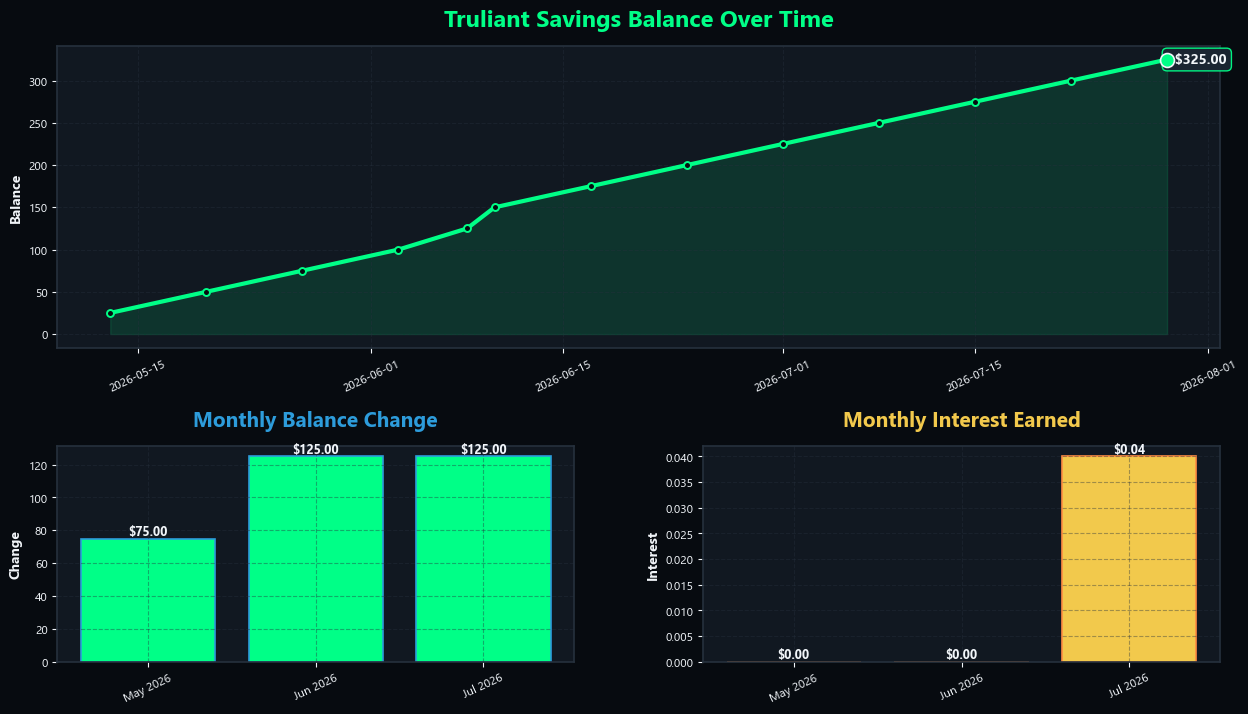

,Date,Description,Type,Amount,Interest,Balance
12,2026-07-29,,Deposit,$25.00,$0.04,$325.00
11,2026-07-22,,Deposit,$25.00,$0.00,$300.00
10,2026-07-15,,Deposit,$25.00,$0.00,$275.00
9,2026-07-08,,Deposit,$25.00,$0.00,$250.00
8,2026-07-01,,Deposit,$25.00,$0.00,$225.00
7,2026-06-24,,Deposit,$25.00,$0.00,$200.00
6,2026-06-17,,Deposit,$25.00,$0.00,$175.00
5,2026-06-10,,Deposit,$25.00,$0.00,$150.00
4,2026-06-08,,Deposit,$25.00,$0.00,$125.00
3,2026-06-03,,Deposit,$25.00,$0.00,$100.00


Truliant Savings Account Summary
---------------------------------------------
Current Balance:   $325.00
Monthly Change:    $0.00
YTD Interest:      $0.04
APY:               0.100%
YTD Deposits:      $325.00
YTD Withdrawals:   $0.00
Latest Excel Date: 2026-07-29
Last Updated:      2026-08-04 11:17:58 AM


In [30]:
# ============================================================
# TRULIANT SAVINGS ONLY DASHBOARD - JUPYTER NOTEBOOK
# ============================================================

import sys
import subprocess
import time
from pathlib import Path
from datetime import datetime

# Install required packages if missing
for package in ["pandas", "openpyxl", "matplotlib", "numpy"]:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output


# ============================================================
# SETTINGS
# ============================================================

EXCEL_PATH = Path(
    r"C:\Users\207133\OneDrive - AmWINS Group, Inc (USA)\Desktop\ExpenseTracker\TruliantSavings.xlsx"
)

SHEET_NAME = 0

# If your Excel file does not have a Balance column,
# the dashboard will calculate balance as:
# STARTING_BALANCE + cumulative Amount
STARTING_BALANCE = 0.00

# Manual Truliant values
YTD_INTEREST_OVERRIDE = 0.04
APY_OVERRIDE = 0.100

# Set True if you want the dashboard to refresh automatically inside Jupyter.
RUN_LIVE = False

REFRESH_SECONDS = 30


# ============================================================
# THEME
# ============================================================

THEME = {
    "bg": "#070B10",
    "panel": "#111821",
    "panel_2": "#1B2633",
    "grid": "#26313D",
    "text": "#F2F6FA",
    "muted": "#9AA7B5",
    "green": "#00FF87",
    "green_dark": "#00C46A",
    "red": "#FF4655",
    "blue": "#2D9CDB",
    "yellow": "#F2C94C",
    "orange": "#FF8C42",
    "purple": "#9B51E0",
}


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def money(value):
    try:
        return f"${float(value):,.2f}"
    except Exception:
        return "$0.00"


def clean_col_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def clean_money_series(series):
    s = series.astype(str).str.strip()
    s = s.str.replace("\u2212", "-", regex=False)

    parentheses_negative = s.str.match(r"^\(.*\)$", na=False)

    s = s.str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("(", "", regex=False)
    s = s.str.replace(")", "", regex=False)

    out = pd.to_numeric(s, errors="coerce")
    out.loc[parentheses_negative] = -out.loc[parentheses_negative].abs()

    return out


def find_column(df, possible_names):
    normalized_cols = {clean_col_name(col): col for col in df.columns}

    for name in possible_names:
        clean_name = clean_col_name(name)

        if clean_name in normalized_cols:
            return normalized_cols[clean_name]

    return None


# ============================================================
# READ TRULIANT EXCEL
# ============================================================

def read_truliant_file():
    if not EXCEL_PATH.exists():
        raise FileNotFoundError(f"Could not find file:\n{EXCEL_PATH}")

    raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, engine="openpyxl")

    if raw.empty:
        raise ValueError("TruliantSavings.xlsx is empty.")

    date_col = find_column(
        raw,
        [
            "Date",
            "Transaction Date",
            "Posted Date",
            "Post Date",
            "Activity Date",
        ],
    )

    description_col = find_column(
        raw,
        [
            "Description",
            "Transaction",
            "Memo",
            "Details",
            "Name",
        ],
    )

    amount_col = find_column(
        raw,
        [
            "Amount",
            "Transaction Amount",
            "Net Amount",
            "Change",
        ],
    )

    deposit_col = find_column(
        raw,
        [
            "Deposit",
            "Deposits",
            "Credit",
            "Credits",
            "Money In",
        ],
    )

    withdrawal_col = find_column(
        raw,
        [
            "Withdrawal",
            "Withdrawals",
            "Debit",
            "Debits",
            "Money Out",
        ],
    )

    balance_col = find_column(
        raw,
        [
            "Balance",
            "Current Balance",
            "Running Balance",
            "Account Balance",
            "Ending Balance",
        ],
    )

    if date_col is None:
        raise ValueError(
            "Could not find a date column. Use a column named Date, Transaction Date, or Posted Date."
        )

    if amount_col is None and balance_col is None and deposit_col is None and withdrawal_col is None:
        raise ValueError(
            "Could not find Amount, Balance, Deposit, or Withdrawal columns. "
            "Your Truliant sheet should have at least Date + Amount or Date + Balance."
        )

    df = pd.DataFrame()

    df["Date"] = pd.to_datetime(raw[date_col], errors="coerce")

    if description_col is not None:
        df["Description"] = raw[description_col].fillna("").astype(str)
    else:
        df["Description"] = ""

    # Amount logic:
    # 1. Use Amount column if available.
    # 2. Else use Deposit - Withdrawal.
    # 3. Else infer from balance changes.
    if amount_col is not None:
        df["Amount"] = clean_money_series(raw[amount_col]).fillna(0)
    else:
        deposits = clean_money_series(raw[deposit_col]).fillna(0) if deposit_col is not None else 0
        withdrawals = clean_money_series(raw[withdrawal_col]).fillna(0) if withdrawal_col is not None else 0
        df["Amount"] = deposits - withdrawals

    if balance_col is not None:
        df["Balance"] = clean_money_series(raw[balance_col])
    else:
        df["Balance"] = np.nan

    df = df.dropna(subset=["Date"]).copy()
    df = df.sort_values("Date").reset_index(drop=True)

    # Balance logic
    if df["Balance"].isna().all():
        df["Balance"] = STARTING_BALANCE + df["Amount"].cumsum()
    else:
        df["Balance"] = df["Balance"].ffill()

        # If there was no amount column, infer changes from balance
        if amount_col is None and deposit_col is None and withdrawal_col is None:
            df["Amount"] = df["Balance"].diff().fillna(0)

    desc_lower = df["Description"].str.lower()

    # Type classification
    df["Type"] = "Other"
    df.loc[df["Amount"] > 0, "Type"] = "Deposit"
    df.loc[df["Amount"] < 0, "Type"] = "Withdrawal"
    df.loc[desc_lower.str.contains("interest|dividend", regex=True, na=False), "Type"] = "Interest"

    # Interest column for charting.
    # This keeps interest chart aligned with your manual YTD value.
    df["Interest"] = 0.0

    interest_rows = desc_lower.str.contains("interest|dividend", regex=True, na=False)

    if interest_rows.any():
        df.loc[interest_rows, "Interest"] = df.loc[interest_rows, "Amount"]

    # If no interest row exists but you have a YTD override,
    # place the YTD interest on the latest date for chart display.
    if df["Interest"].abs().sum() == 0 and YTD_INTEREST_OVERRIDE != 0:
        df.loc[df.index[-1], "Interest"] = YTD_INTEREST_OVERRIDE

    detected_columns = {
        "Date": date_col,
        "Description": description_col,
        "Amount": amount_col,
        "Deposit": deposit_col,
        "Withdrawal": withdrawal_col,
        "Balance": balance_col,
    }

    return df, detected_columns


# ============================================================
# SUMMARY
# ============================================================

def get_truliant_summary(df):
    today = pd.Timestamp.today()
    current_year = today.year
    current_month = today.month

    latest_row = df.sort_values("Date").iloc[-1]

    current_balance = float(latest_row["Balance"])
    latest_date = latest_row["Date"]

    year_df = df[df["Date"].dt.year == current_year].copy()

    month_df = df[
        (df["Date"].dt.year == current_year)
        & (df["Date"].dt.month == current_month)
    ].copy()

    monthly_change = float(month_df["Amount"].sum()) if not month_df.empty else 0.0

    # Manual Truliant values
    ytd_interest = YTD_INTEREST_OVERRIDE
    latest_apy = APY_OVERRIDE

    ytd_deposits = (
        float(year_df.loc[year_df["Amount"] > 0, "Amount"].sum())
        if not year_df.empty
        else 0.0
    )

    ytd_withdrawals = (
        float(year_df.loc[year_df["Amount"] < 0, "Amount"].sum())
        if not year_df.empty
        else 0.0
    )

    return {
        "current_balance": current_balance,
        "monthly_change": monthly_change,
        "ytd_interest": ytd_interest,
        "ytd_deposits": ytd_deposits,
        "ytd_withdrawals": ytd_withdrawals,
        "latest_apy": latest_apy,
        "latest_date": latest_date,
        "updated_at": datetime.now(),
    }


# ============================================================
# DISPLAY HEADER CARDS
# ============================================================

def display_header(summary):
    current_balance = summary["current_balance"]
    monthly_change = summary["monthly_change"]
    ytd_interest = summary["ytd_interest"]
    latest_apy = summary["latest_apy"]
    latest_date = summary["latest_date"]
    updated_at = summary["updated_at"]

    monthly_color = THEME["green"] if monthly_change >= 0 else THEME["red"]
    apy_text = f"{latest_apy:.3f}%"

    html = f"""
    <div style="
        background: radial-gradient(circle at top left, #13213A 0%, {THEME['bg']} 45%, #050914 100%);
        padding: 26px;
        border-radius: 18px;
        color: {THEME['text']};
        font-family: Arial, sans-serif;
        border: 1px solid {THEME['grid']};
    ">
        <h1 style="
            color: {THEME['green']};
            margin-bottom: 4px;
            text-shadow: 0 0 16px rgba(0,255,135,0.45);
        ">
            Truliant Savings Account
        </h1>

        <p style="color: {THEME['muted']}; margin-top: 0;">
            Dedicated Truliant savings dashboard · Updated {updated_at.strftime("%Y-%m-%d %I:%M:%S %p")}
        </p>

        <div style="display: flex; gap: 16px; margin-top: 22px; flex-wrap: wrap;">

            <div style="
                background: {THEME['panel']};
                border: 1px solid {THEME['green']};
                border-radius: 14px;
                padding: 20px;
                min-width: 300px;
            ">
                <div style="color: {THEME['muted']}; font-size: 13px;">CURRENT TRULIANT BALANCE</div>
                <div style="color: {THEME['green']}; font-size: 42px; font-weight: 900;">
                    {money(current_balance)}
                </div>
            </div>

            <div style="
                background: {THEME['panel']};
                border: 1px solid {monthly_color};
                border-radius: 14px;
                padding: 20px;
                min-width: 230px;
            ">
                <div style="color: {THEME['muted']}; font-size: 13px;">MONTH CHANGE</div>
                <div style="color: {monthly_color}; font-size: 30px; font-weight: 900;">
                    {money(monthly_change)}
                </div>
            </div>

            <div style="
                background: {THEME['panel']};
                border: 1px solid {THEME['yellow']};
                border-radius: 14px;
                padding: 20px;
                min-width: 230px;
            ">
                <div style="color: {THEME['muted']}; font-size: 13px;">YTD INTEREST</div>
                <div style="color: {THEME['yellow']}; font-size: 30px; font-weight: 900;">
                    {money(ytd_interest)}
                </div>
            </div>

            <div style="
                background: {THEME['panel']};
                border: 1px solid {THEME['blue']};
                border-radius: 14px;
                padding: 20px;
                min-width: 230px;
            ">
                <div style="color: {THEME['muted']}; font-size: 13px;">APY</div>
                <div style="color: {THEME['blue']}; font-size: 30px; font-weight: 900;">
                    {apy_text}
                </div>
            </div>

        </div>

        <div style="display: flex; gap: 16px; margin-top: 16px; flex-wrap: wrap;">

            <div style="
                background: {THEME['panel']};
                border: 1px solid {THEME['grid']};
                border-radius: 14px;
                padding: 14px;
                min-width: 220px;
            ">
                <div style="color: {THEME['muted']}; font-size: 12px;">YTD DEPOSITS</div>
                <div style="color: {THEME['green']}; font-size: 22px; font-weight: 900;">
                    {money(summary['ytd_deposits'])}
                </div>
            </div>

            <div style="
                background: {THEME['panel']};
                border: 1px solid {THEME['grid']};
                border-radius: 14px;
                padding: 14px;
                min-width: 220px;
            ">
                <div style="color: {THEME['muted']}; font-size: 12px;">YTD WITHDRAWALS</div>
                <div style="color: {THEME['red']}; font-size: 22px; font-weight: 900;">
                    {money(summary['ytd_withdrawals'])}
                </div>
            </div>

            <div style="
                background: {THEME['panel']};
                border: 1px solid {THEME['grid']};
                border-radius: 14px;
                padding: 14px;
                min-width: 220px;
            ">
                <div style="color: {THEME['muted']}; font-size: 12px;">LATEST EXCEL DATE</div>
                <div style="color: {THEME['text']}; font-size: 22px; font-weight: 900;">
                    {latest_date.strftime("%Y-%m-%d")}
                </div>
            </div>

        </div>
    </div>
    """

    display(HTML(html))


# ============================================================
# DISPLAY CHARTS
# ============================================================

def display_truliant_charts(df):
    plt.rcParams["figure.facecolor"] = THEME["bg"]
    plt.rcParams["axes.facecolor"] = THEME["panel"]
    plt.rcParams["savefig.facecolor"] = THEME["bg"]
    plt.rcParams["text.color"] = THEME["text"]
    plt.rcParams["axes.labelcolor"] = THEME["text"]
    plt.rcParams["xtick.color"] = THEME["text"]
    plt.rcParams["ytick.color"] = THEME["text"]

    fig = plt.figure(figsize=(15, 8), facecolor=THEME["bg"])
    gs = fig.add_gridspec(2, 2, height_ratios=[1.4, 1], hspace=0.38, wspace=0.25)

    ax_balance = fig.add_subplot(gs[0, :])
    ax_change = fig.add_subplot(gs[1, 0])
    ax_interest = fig.add_subplot(gs[1, 1])

    for ax in [ax_balance, ax_change, ax_interest]:
        ax.set_facecolor(THEME["panel"])
        ax.grid(True, color=THEME["grid"], linestyle="--", alpha=0.40)
        ax.tick_params(colors=THEME["text"])

        for spine in ax.spines.values():
            spine.set_color(THEME["grid"])
            spine.set_linewidth(1.2)

    # Balance line chart
    ax_balance.plot(
        df["Date"],
        df["Balance"],
        color=THEME["green"],
        linewidth=3,
        marker="o",
        markersize=5,
        markerfacecolor=THEME["bg"],
        markeredgecolor=THEME["green"],
        markeredgewidth=1.4,
    )

    ax_balance.fill_between(
        df["Date"],
        df["Balance"],
        0,
        color=THEME["green"],
        alpha=0.12,
    )

    latest = df.iloc[-1]

    ax_balance.scatter(
        latest["Date"],
        latest["Balance"],
        s=100,
        color=THEME["green"],
        edgecolor=THEME["text"],
        linewidth=1.2,
        zorder=5,
    )

    ax_balance.text(
        latest["Date"],
        latest["Balance"],
        f"  {money(latest['Balance'])}",
        va="center",
        color=THEME["text"],
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor=THEME["panel_2"],
            edgecolor=THEME["green"],
            boxstyle="round,pad=0.35",
            alpha=0.95,
        ),
    )

    ax_balance.set_title(
        "Truliant Savings Balance Over Time",
        color=THEME["green"],
        fontsize=17,
        fontweight="bold",
        pad=14,
    )

    ax_balance.set_ylabel("Balance")
    ax_balance.tick_params(axis="x", rotation=25)

    # Monthly net change chart
    monthly_change = (
        df.set_index("Date")
        .resample("M")["Amount"]
        .sum()
        .reset_index()
    )

    change_colors = [
        THEME["green"] if value >= 0 else THEME["red"]
        for value in monthly_change["Amount"]
    ]

    bars_change = ax_change.bar(
        monthly_change["Date"].dt.strftime("%b %Y"),
        monthly_change["Amount"],
        color=change_colors,
        edgecolor=THEME["blue"],
        linewidth=1.2,
    )

    ax_change.set_title(
        "Monthly Balance Change",
        color=THEME["blue"],
        fontsize=15,
        fontweight="bold",
        pad=14,
    )

    ax_change.set_ylabel("Change")
    ax_change.tick_params(axis="x", rotation=25)

    for bar, value in zip(bars_change, monthly_change["Amount"]):
        va = "bottom" if value >= 0 else "top"
        ax_change.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            money(value),
            ha="center",
            va=va,
            color=THEME["text"],
            fontsize=9,
            fontweight="bold",
        )

    # Monthly interest chart
    monthly_interest = (
        df.set_index("Date")
        .resample("M")["Interest"]
        .sum()
        .reset_index()
    )

    bars_interest = ax_interest.bar(
        monthly_interest["Date"].dt.strftime("%b %Y"),
        monthly_interest["Interest"],
        color=THEME["yellow"],
        edgecolor=THEME["orange"],
        linewidth=1.2,
    )

    ax_interest.set_title(
        "Monthly Interest Earned",
        color=THEME["yellow"],
        fontsize=15,
        fontweight="bold",
        pad=14,
    )

    ax_interest.set_ylabel("Interest")
    ax_interest.tick_params(axis="x", rotation=25)

    for bar, value in zip(bars_interest, monthly_interest["Interest"]):
        ax_interest.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            money(value),
            ha="center",
            va="bottom",
            color=THEME["text"],
            fontsize=9,
            fontweight="bold",
        )

    plt.show()


# ============================================================
# DISPLAY RECENT TRULIANT ACTIVITY ONLY
# ============================================================

def display_recent_activity(df):
    recent = df.sort_values("Date", ascending=False).head(10).copy()

    recent["Date"] = recent["Date"].dt.strftime("%Y-%m-%d")
    recent["Amount"] = recent["Amount"].map(money)
    recent["Interest"] = recent["Interest"].map(money)
    recent["Balance"] = recent["Balance"].map(money)

    display(
        HTML(
            f"""
            <h2 style="color:{THEME['green']}; font-family:Arial; margin-top:24px;">
                Recent Truliant Activity
            </h2>
            """
        )
    )

    display(recent[["Date", "Description", "Type", "Amount", "Interest", "Balance"]])


# ============================================================
# RUN DASHBOARD
# ============================================================

def run_truliant_dashboard():
    df, detected_columns = read_truliant_file()
    summary = get_truliant_summary(df)

    display_header(summary)
    display_truliant_charts(df)
    display_recent_activity(df)

    print("Truliant Savings Account Summary")
    print("-" * 45)
    print(f"Current Balance:   {money(summary['current_balance'])}")
    print(f"Monthly Change:    {money(summary['monthly_change'])}")
    print(f"YTD Interest:      {money(summary['ytd_interest'])}")
    print(f"APY:               {summary['latest_apy']:.3f}%")
    print(f"YTD Deposits:      {money(summary['ytd_deposits'])}")
    print(f"YTD Withdrawals:   {money(summary['ytd_withdrawals'])}")
    print(f"Latest Excel Date: {summary['latest_date'].strftime('%Y-%m-%d')}")
    print(f"Last Updated:      {summary['updated_at'].strftime('%Y-%m-%d %I:%M:%S %p')}")


if RUN_LIVE:
    while True:
        clear_output(wait=True)

        try:
            run_truliant_dashboard()

            display(
                HTML(
                    f"""
                    <div style="
                        color:{THEME['muted']};
                        font-family:Arial;
                        margin-top:12px;
                    ">
                        Truliant-only live dashboard is running.
                        Save TruliantSavings.xlsx, and this notebook will update.
                        Next refresh in {REFRESH_SECONDS} seconds.
                        To stop, click the Jupyter stop button.
                    </div>
                    """
                )
            )

        except Exception as e:
            display(
                HTML(
                    f"""
                    <div style="
                        background:{THEME['panel']};
                        color:{THEME['red']};
                        border:1px solid {THEME['red']};
                        border-radius:12px;
                        padding:16px;
                        font-family:Arial;
                    ">
                        <h3>Error loading Truliant dashboard</h3>
                        <pre>{e}</pre>
                    </div>
                    """
                )
            )
            break

        time.sleep(REFRESH_SECONDS)

else:
    run_truliant_dashboard()